# Trích xuất Loại Đất từ Quy Hoạch HCMC

Pipeline:
1. Đọc CSV crawl được (có cột `Latitude`, `Longitude` theo WGS84 từ Google Maps)
2. Chuyển đổi sang hệ tọa độ **VN2000** (Transverse Mercator, múi 48, kinh tuyến trục 105°)
3. Gọi API `thongtinquyhoach.hochiminhcity.gov.vn` để lấy loại đất tại từng toạ độ
4. Ghi kết quả ra CSV mới

## 1. Cài đặt thư viện

In [1]:
!pip install requests pandas tqdm

## 2. Import & cấu hình

In [2]:
import math
import time
import requests
import pandas as pd
from tqdm.notebook import tqdm

# ── Cấu hình ────────────────────────────────────────────────────────────────
INPUT_CSV  = "data_bds.csv"   # <-- đường dẫn tới file CSV đầu vào
OUTPUT_CSV = "data_bds_with_landuse.csv"

# Delay giữa các request (giây) — tránh bị block IP
REQUEST_DELAY = 0.5

# Số lần retry khi request thất bại
MAX_RETRY = 3

## 4. Hàm gọi API thongtinquyhoach.hochiminhcity.gov.vn

In [3]:
import requests
import json
import csv
import time

def lay_thong_tin_quy_hoach(lat, lon):
    """
    Hàm gọi API và trả về một dictionary chứa các thông tin quy hoạch trích xuất được.
    """
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    headers = {
        "Host": "sqhkt-qlqh.tphcm.gov.vn",
        "Accept": "application/json, text/plain, */*",
        "Content-Type": "application/x-www-form-urlencoded",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
        "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
        "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
    }
    data = {"Lat": lat, "Lon": lon}
    
    # Dictionary chứa giá trị mặc định nếu không tìm thấy dữ liệu
    ket_qua = {
        "Quan_Huyen": "",
        "Phuong_Xa": "",
        "Dien_Tich": "",
        "Chuc_Nang_QHPK": "",
        "Ten_Do_An": "",
        "Trang_Thai": "Thành công"
    }

    try:
        response = requests.post(url, headers=headers, data=data, timeout=10)
        response.raise_for_status()
        result = response.json()
        
        # Kiểm tra xem IP có bị block không
        if result.get("blocked") == 1:
            ket_qua["Trang_Thai"] = "Bị chặn IP"
            return ket_qua

        # 1. Bóc tách Thông tin chung
        if "ThongTinChung" in result and result["ThongTinChung"] not in ("[]", "{}"):
            try:
                thong_tin_chung = json.loads(result["ThongTinChung"])
                ket_qua["Quan_Huyen"] = thong_tin_chung.get("tenquanhuyen", "")
                ket_qua["Phuong_Xa"] = thong_tin_chung.get("tenphuongxa", "")
                ket_qua["Dien_Tich"] = thong_tin_chung.get("dientich", "")
                
                if "dsdoan" in thong_tin_chung and isinstance(thong_tin_chung["dsdoan"], list):
                    ket_qua["Ten_Do_An"] = " | ".join(thong_tin_chung["dsdoan"])
            except json.JSONDecodeError:
                ket_qua["Trang_Thai"] = "Lỗi parse JSON Thông Tin Chung"

        # 2. Bóc tách Quy hoạch phân khu (Lấy chức năng đầu tiên làm đại diện)
        if "QHPK" in result and result["QHPK"] not in ("[]", "{}"):
            try:
                qhpk = json.loads(result["QHPK"])
                if len(qhpk) > 0:
                    props = qhpk[0].get("properties", {})
                    ket_qua["Chuc_Nang_QHPK"] = props.get("chucnang", "")
            except json.JSONDecodeError:
                 ket_qua["Trang_Thai"] = "Lỗi parse JSON QHPK"

    except requests.exceptions.RequestException as e:
        ket_qua["Trang_Thai"] = f"Lỗi mạng/API: {e}"
    except Exception as e:
        ket_qua["Trang_Thai"] = f"Lỗi không xác định: {e}"

    return ket_qua


def xu_ly_file_csv(file_dau_vao, file_dau_ra):
    try:
        # Mở file đọc và ghi đồng thời
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_in, \
             open(file_dau_ra, mode='w', encoding='utf-8-sig', newline='') as f_out:
            
            reader = csv.DictReader(f_in)
            
            # Cột gốc ban đầu
            cac_cot_goc = reader.fieldnames
            if not cac_cot_goc or 'Latitude' not in cac_cot_goc or 'Longitude' not in cac_cot_goc:
                print("❌ File CSV đầu vào bắt buộc phải có 2 cột 'Latitude' và 'Longitude'.")
                return

            # Thêm các cột mới sẽ bổ sung vào
            cac_cot_moi = ["Quan_Huyen", "Phuong_Xa", "Dien_Tich", "Chuc_Nang_QHPK", "Ten_Do_An", "Trang_Thai"]
            toan_bo_cot = cac_cot_goc + cac_cot_moi
            
            writer = csv.DictWriter(f_out, fieldnames=toan_bo_cot)
            writer.writeheader()
            
            # ==========================================
            # CÁCH ĐẾM ĐÚNG SỐ LƯỢNG MẪU (LOGICAL ROWS)
            # ==========================================
            # Mở file một lần nữa một cách độc lập để đếm, thư viện csv sẽ tự động 
            # gộp các dấu Enter bên trong ngoặc kép lại thành 1 dòng mẫu duy nhất.
            with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_count:
                reader_count = csv.DictReader(f_count)
                tong_so_dong = sum(1 for _ in reader_count)
                
            print(f"Bắt đầu xử lý {tong_so_dong} mẫu dữ liệu...\n")
            
            # [ĐÃ XÓA]: f_in.seek(0) và next(reader)
            # Vì reader.fieldnames ở trên đã tự động đọc qua dòng tiêu đề rồi, 
            # nên con trỏ 'reader' hiện tại đã nằm đúng vị trí của mẫu dữ liệu đầu tiên.

            # Lặp qua từng dòng dữ liệu
            for index, row in enumerate(reader, 1):
                lat = row.get("Latitude", "").strip()
                lon = row.get("Longitude", "").strip()
                
                print(f"[{index}/{tong_so_dong}] Đang truy vấn tọa độ: {lat}, {lon}...")
                
                if lat and lon:
                    thong_tin = lay_thong_tin_quy_hoach(lat, lon)
                    # Cập nhật dictionary dòng hiện tại với dữ liệu mới
                    row.update(thong_tin)
                else:
                    row["Trang_Thai"] = "Thiếu tọa độ"

                # Ghi dòng dữ liệu đã bổ sung vào file mới
                writer.writerow(row)
                
                # Nghỉ 1 giây để tránh bị server chặn IP vì gửi request quá nhanh
                time.sleep(1)
                
        print("\n✅ Xử lý hoàn tất! File kết quả đã được lưu tại:", file_dau_ra)

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'. Vui lòng kiểm tra lại đường dẫn.")
    except Exception as e:
        print(f"❌ Có lỗi xảy ra trong quá trình xử lý file: {e}")

In [4]:
if __name__ == "__main__":
    file_in = "data_bds.csv"
    file_out = "output.csv"
    xu_ly_file_csv(file_in, file_out)

❌ Không tìm thấy file 'data_bds.csv'. Vui lòng kiểm tra lại đường dẫn.


In [5]:
import requests
import json
import csv
import time

# ==========================================
# CẤU HÌNH TÊN FILE TẠI ĐÂY
# ==========================================
FILE_INPUT = "data_bds.csv"  # Đổi tên file đầu vào của bạn ở đây
FILE_OUTPUT = "new_data_bds.csv"  # Đổi tên file kết quả đầu ra ở đây
# ==========================================

def lay_thong_tin_quy_hoach(lat, lon):
    """
    Hàm gọi API và trả về một dictionary chứa các thông tin quy hoạch trích xuất được.
    """
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    headers = {
        "Host": "sqhkt-qlqh.tphcm.gov.vn",
        "Accept": "application/json, text/plain, */*",
        "Content-Type": "application/x-www-form-urlencoded",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
        "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
        "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
    }
    data = {"Lat": lat, "Lon": lon}
    
    # Dictionary chứa giá trị mặc định nếu không tìm thấy dữ liệu
    ket_qua = {
        "Quan_Huyen": "",
        "Phuong_Xa": "",
        "Dien_Tich": "",
        "Chuc_Nang_QHPK": "",
        "Ten_Do_An": "",
        "Trang_Thai": "Thành công"
    }

    try:
        response = requests.post(url, headers=headers, data=data, timeout=10)
        response.raise_for_status()
        result = response.json()
        
        # Kiểm tra xem IP có bị block không
        if result.get("blocked") == 1:
            ket_qua["Trang_Thai"] = "Bị chặn IP"
            return ket_qua

        # 1. Bóc tách Thông tin chung
        if "ThongTinChung" in result and result["ThongTinChung"] not in ("[]", "{}"):
            try:
                thong_tin_chung = json.loads(result["ThongTinChung"])
                ket_qua["Quan_Huyen"] = thong_tin_chung.get("tenquanhuyen", "")
                ket_qua["Phuong_Xa"] = thong_tin_chung.get("tenphuongxa", "")
                ket_qua["Dien_Tich"] = thong_tin_chung.get("dientich", "")
                
                if "dsdoan" in thong_tin_chung and isinstance(thong_tin_chung["dsdoan"], list):
                    ket_qua["Ten_Do_An"] = " | ".join(thong_tin_chung["dsdoan"])
            except json.JSONDecodeError:
                ket_qua["Trang_Thai"] = "Lỗi parse JSON Thông Tin Chung"

        # 2. Bóc tách Quy hoạch phân khu (Lấy chức năng đầu tiên làm đại diện)
        if "QHPK" in result and result["QHPK"] not in ("[]", "{}"):
            try:
                qhpk = json.loads(result["QHPK"])
                if len(qhpk) > 0:
                    props = qhpk[0].get("properties", {})
                    ket_qua["Chuc_Nang_QHPK"] = props.get("chucnang", "")
            except json.JSONDecodeError:
                 ket_qua["Trang_Thai"] = "Lỗi parse JSON QHPK"

    except requests.exceptions.RequestException as e:
        ket_qua["Trang_Thai"] = f"Lỗi mạng/API: {e}"
    except Exception as e:
        ket_qua["Trang_Thai"] = f"Lỗi không xác định: {e}"

    return ket_qua


def xu_ly_file_csv(file_dau_vao, file_dau_ra):
    try:
        # Mở file đọc và ghi đồng thời
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_in, \
             open(file_dau_ra, mode='w', encoding='utf-8-sig', newline='') as f_out:
            
            reader = csv.DictReader(f_in)
            
            # Cột gốc ban đầu (Sẽ tự động nhận diện cột Link, Latitude, Longitude)
            cac_cot_goc = reader.fieldnames
            if not cac_cot_goc or 'Latitude' not in cac_cot_goc or 'Longitude' not in cac_cot_goc:
                print("❌ File CSV đầu vào bắt buộc phải có 2 cột 'Latitude' và 'Longitude'.")
                return

            # Thêm các cột mới sẽ bổ sung vào
            cac_cot_moi = ["Quan_Huyen", "Phuong_Xa", "Dien_Tich", "Chuc_Nang_QHPK", "Ten_Do_An", "Trang_Thai"]
            
            # Tổng hợp toàn bộ cột: [Link, Latitude, Longitude] + [Các cột từ API]
            toan_bo_cot = cac_cot_goc + cac_cot_moi
            
            writer = csv.DictWriter(f_out, fieldnames=toan_bo_cot)
            writer.writeheader()
            
            # Đếm dòng bằng list(csv.DictReader) để lấy số dòng dữ liệu thực tế
            with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_count:
                tong_so_dong = len(list(csv.DictReader(f_count)))
            
            print(f"Bắt đầu xử lý {tong_so_dong} dòng dữ liệu thực tế...\n")
            
            # [ĐÃ SỬA LỖI]: Bỏ hoàn toàn f_in.seek(0) và next(reader) để tránh lỗi tràn bộ đệm CSV bẻ gãy vòng lặp ở dòng 100.

            # Lặp qua từng dòng dữ liệu từ đầu đến cuối file một cách tự nhiên
            for index, row in enumerate(reader, 1):
                link_khoa_chinh = row.get("Link", "Không có link")
                lat = row.get("Latitude", "").strip()
                lon = row.get("Longitude", "").strip()
                
                # In log để theo dõi tiến độ
                print(f"[{index}/{tong_so_dong}] Đang xử lý Link: {link_khoa_chinh} | Tọa độ: {lat}, {lon}...")
                
                if lat and lon:
                    thong_tin = lay_thong_tin_quy_hoach(lat, lon)
                    # Cập nhật dữ liệu mới lấy từ API vào dòng hiện tại
                    row.update(thong_tin)
                else:
                    row["Trang_Thai"] = "Thiếu tọa độ"

                # Ghi dòng dữ liệu đã bổ sung vào file mới
                writer.writerow(row)
                
                # Nghỉ 3 giây để tránh bị server chặn IP
                time.sleep(0.5)
                
        print("\n✅ Xử lý hoàn tất thực sự toàn bộ file! File kết quả đã được lưu tại:", file_dau_ra)

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'. Vui lòng kiểm tra lại đường dẫn.")
    except Exception as e:
        print(f"❌ Có lỗi xảy ra trong quá trình xử lý file: {e}")

In [6]:
if __name__ == "__main__":
    xu_ly_file_csv(FILE_INPUT, FILE_OUTPUT)

❌ Không tìm thấy file 'data_bds.csv'. Vui lòng kiểm tra lại đường dẫn.


kiểm tra lỗi Mạng/API

In [7]:
import requests
import json
import ast
import time

def test_api_toa_do(lat, lon, max_retries=3, backoff_factor=3):
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    headers = {
        "Host": "sqhkt-qlqh.tphcm.gov.vn",
        "Accept": "application/json, text/plain, */*",
        "Content-Type": "application/x-www-form-urlencoded",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
        "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
        "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
    }
    data = {"Lat": lat, "Lon": lon}
    
    print(f"🛰️  Đang gửi request test với tọa độ: {lat}, {lon}...")
    print("-" * 60)
    
    # Cơ chế Trị lỗi mạng chập chờn bằng Vòng lặp Retry
    for attempt in range(1, max_retries + 1):
        try:
            if attempt > 1:
                sleep_time = backoff_factor * (attempt - 1)
                print(f"⏳ Mạng lỗi ở lượt trước. Đang thử lại lần {attempt}/{max_retries} (Nghỉ {sleep_time}s để né Firewall)...")
                time.sleep(sleep_time)
                
            response = requests.post(url, headers=headers, data=data, timeout=15)
            
            # 1. Kiểm tra mã trạng thái HTTP trước
            print(f"🔹 Mã phản hồi HTTP (Status Code): {response.status_code}")
            
            if response.status_code != 200:
                print(f"⚠️ Server trả lỗi HTTP {response.status_code}. Thử lại lượt sau...")
                continue
            
            # 2. Đọc dữ liệu thô
            raw_text = response.text.strip() if response.text else ""
            print("\n📄 [DỮ LIỆU THÔ - RAW TEXT CHƯA PARSE]")
            print("=" * 60)
            print(raw_text if raw_text else "[Trống rỗng - Server không trả về chữ nào]")
            print("=" * 60)
            
            # 3. Cơ chế Ép kiểu thông minh trị Lỗi thiếu nhất quán định dạng
            print("\n🔍 Tiến hành bóc tách dữ liệu (.json())...")
            result_data = None
            
            try:
                # Cách A: Thử ép kiểu chuẩn JSON (Khi server trả về dấu nháy kép "")
                result_data = response.json()
                print("✅ Thành công! Server trả về JSON chuẩn chỉnh.")
            except (json.JSONDecodeError, ValueError):
                # Cách B: Kích hoạt cứu viện nếu dính dấu nháy đơn '' kiểu {'error': '...'}
                print("⚠️ Thất bại với json.loads(). Đang kích hoạt bộ giải mã chuỗi Python (ast.literal_eval)...")
                try:
                    result_data = ast.literal_eval(raw_text)
                    print("✅ Cứu dữ liệu thành công! Chuỗi nháy đơn đã được chuyển hóa thành Dict.")
                except Exception as parse_err:
                    print(f"❌ Kịch bản xấu nhất: D dữ liệu lỗi hoàn toàn không thể parse. Chi tiết: {parse_err}")
                    return None
            
            # 4. Kiểm tra xem dữ liệu là data thật hay là thông báo lỗi từ Server
            if isinstance(result_data, dict) and "error" in result_data:
                print(f"🛑 Server phản hồi thành công nhưng chặn dữ liệu với lý do: '{result_data['error']}'")
                return result_data
                
            # Nếu lấy được data xịn, thoát vòng lặp và trả về kết quả
            return result_data
            
        except requests.exceptions.Timeout:
            print(f"❌ Lần {attempt}: Hết hạn kết nối (Timeout 15s). Có thể dính Firewall chặn cứng gói tin.")
            if attempt == max_retries:
                print("🚨 Đã thử lại tối đa số lần cho phép. Xác định sập kết nối!")
                return None
        except requests.exceptions.RequestException as req_err:
            print(f"❌ Lần {attempt}: Lỗi kết nối/Mạng: {req_err}")
            if attempt == max_retries:
                return None
        except Exception as e:
            print(f"❌ Lỗi không xác định: {e}")
            return None

if __name__ == "__main__":
    # Test tọa độ dính lỗi "The land is temporarily locked!"
    LATITUDE = "10.8359547395213"
    LONGITUDE = "106.843016346979"
    
    final_result = test_api_toa_do(LATITUDE, LONGITUDE)
    print("\n📊 KẾT QUẢ CUỐI CÙNG TRẢ VỀ CHO TOOL:")
    print(final_result)

🛰️  Đang gửi request test với tọa độ: 10.8359547395213, 106.843016346979...
------------------------------------------------------------
🔹 Mã phản hồi HTTP (Status Code): 200

📄 [DỮ LIỆU THÔ - RAW TEXT CHƯA PARSE]
{'error' : 'The land is temporarily locked!'}

🔍 Tiến hành bóc tách dữ liệu (.json())...
⚠️ Thất bại với json.loads(). Đang kích hoạt bộ giải mã chuỗi Python (ast.literal_eval)...
✅ Cứu dữ liệu thành công! Chuỗi nháy đơn đã được chuyển hóa thành Dict.
🛑 Server phản hồi thành công nhưng chặn dữ liệu với lý do: 'The land is temporarily locked!'

📊 KẾT QUẢ CUỐI CÙNG TRẢ VỀ CHO TOOL:
{'error': 'The land is temporarily locked!'}


In [8]:
import ast
import csv
import json
import time
import requests

# ==========================================
# CẤU HÌNH TÊN FILE TẠI ĐÂY
# ==========================================
FILE_INPUT = "/data/raw_bds_data.csv"
FILE_OUTPUT = "/data/raw_data.csv"
MAX_RETRY = 3          # Số lần thử lại tối đa khi mạng rớt hoặc timeout
BACKOFF_FACTOR = 3     # Hệ số thời gian nghỉ tăng dần khi thử lại
# ==========================================

# Khởi tạo Session để tái sử dụng TCP Connection, giúp tăng tốc độ gọi API và né Firewall
session = requests.Session()
session.headers.update({
    "Host": "sqhkt-qlqh.tphcm.gov.vn",
    "Accept": "application/json, text/plain, */*",
    "Content-Type": "application/x-www-form-urlencoded",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
    "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
    "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
})

def lay_thong_tin_quy_hoach_v2(lat, lon):
    """
    Hàm gọi API thế hệ mới (Sử dụng trực tiếp Lat/Lon, không tự ý chuyển đổi hệ quy chiếu).
    Đã bọc cơ chế Exponential Backoff chống Timeout và ast.literal_eval trị chuỗi lỗi nháy đơn.
    """
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    data = {"Lat": lat, "Lon": lon}
    
    # Giá trị mặc định trả về cho mỗi dòng
    ket_qua = {
        "Quan_Huyen": "",
        "Phuong_Xa": "",
        "Dien_Tich": "",
        "Chuc_Nang_QHPK": "",
        "Ten_Do_An": "",
        "Trang_Thai": "Thành công"
    }

    for attempt in range(1, MAX_RETRY + 1):
        try:
            # Cơ chế nghỉ tăng dần nếu lượt trước bị lỗi mạng/timeout
            if attempt > 1:
                sleep_time = BACKOFF_FACTOR * (attempt - 1)
                time.sleep(sleep_time)
                
            response = session.post(url, data=data, timeout=15)
            
            # Nếu Server lỗi cứng (Ví dụ 500, 502, 404), không cố thử lại vô ích
            if response.status_code != 200:
                ket_qua["Trang_Thai"] = f"Lỗi HTTP {response.status_code}"
                return ket_qua
                
            raw_text = response.text.strip() if response.text else ""
            if not raw_text:
                ket_qua["Trang_Thai"] = "Server trả về rỗng"
                return ket_qua

            # --- BẮT ĐẦU ÉP KIỂU THÔNG MINH (TRỊ LỖI THIẾU NHẤT QUÁN) ---
            result_data = None
            try:
                # Cách 1: Parse JSON chuẩn chỉnh (Dấu nháy kép)
                result_data = response.json()
            except (json.JSONDecodeError, ValueError):
                try:
                    # Cách 2: Cứu viện bằng bộ giải mã chuỗi Python (Dấu nháy đơn từ lỗi hệ thống của họ)
                    result_data = ast.literal_eval(raw_text)
                except Exception:
                    ket_qua["Trang_Thai"] = f"Lỗi cấu trúc dữ liệu lạ: {raw_text[:50]}"
                    return ket_qua

            # Nếu lọt vào Dict lỗi hệ thống khóa đất của họ: {'error': 'The land is temporarily locked!'}
            if isinstance(result_data, dict) and "error" in result_data:
                ket_qua["Trang_Thai"] = f"Bị khóa: {result_data['error']}"
                return ket_qua
                
            if result_data.get("blocked") == 1:
                ket_qua["Trang_Thai"] = "Bị chặn IP"
                return ket_qua

            # --- BÓC TÁCH DỮ LIỆU SAU KHI NẠP THÀNH CÔNG ---
            # 1. Bóc tách Thông tin chung
            if "ThongTinChung" in result_data and result_data["ThongTinChung"] not in ("[]", "{}"):
                try:
                    # Vì Server họ bọc JSON lồng trong String, nên ta phải loads thêm 1 lần nữa
                    tt_chung_str = result_data["ThongTinChung"]
                    thong_tin_chung = json.loads(tt_chung_str) if isinstance(tt_chung_str, str) else tt_chung_str
                    
                    if isinstance(thong_tin_chung, dict):
                        ket_qua["Quan_Huyen"] = thong_tin_chung.get("tenquanhuyen", "")
                        ket_qua["Phuong_Xa"] = thong_tin_chung.get("tenphuongxa", "")
                        ket_qua["Dien_Tich"] = thong_tin_chung.get("dientich", "")
                        
                        if "dsdoan" in thong_tin_chung and isinstance(thong_tin_chung["dsdoan"], list):
                            ket_qua["Ten_Do_An"] = " | ".join(thong_tin_chung["dsdoan"])
                except Exception:
                    ket_qua["Trang_Thai"] = "Lỗi bóc tách Thông Tin Chung"

            # 2. Bóc tách Quy hoạch phân khu (QHPK)
            if "QHPK" in result_data and result_data["QHPK"] not in ("[]", "{}"):
                try:
                    qhpk_str = result_data["QHPK"]
                    qhpk = json.loads(qhpk_str) if isinstance(qhpk_str, str) else qhpk_str
                    if isinstance(qhpk, list) and len(qhpk) > 0:
                        props = qhpk[0].get("properties", {})
                        ket_qua["Chuc_Nang_QHPK"] = props.get("chucnang", "")
                except Exception:
                     ket_qua["Trang_Thai"] = "Lỗi bóc tách QHPK"

            return ket_qua  # Lấy dữ liệu thành công hoàn toàn

        except requests.exceptions.Timeout:
            if attempt == MAX_RETRY:
                ket_qua["Trang_Thai"] = "Mạng Timeout (Hết lượt thử lại)"
                return ket_qua
        except requests.exceptions.RequestException as e:
            if attempt == MAX_RETRY:
                ket_qua["Trang_Thai"] = f"Lỗi mạng: {str(e)[:50]}"
                return ket_qua
        except Exception as e:
            ket_qua["Trang_Thai"] = f"Lỗi không xác định: {str(e)[:50]}"
            return ket_qua
            
    return ket_qua


def xu_ly_file_csv(file_dau_vao, file_dau_ra):
    try:
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_in, \
             open(file_dau_ra, mode='w', encoding='utf-8-sig', newline='') as f_out:
            
            reader = csv.DictReader(f_in)
            cac_cot_goc = reader.fieldnames
            
            if not cac_cot_goc or 'Latitude' not in cac_cot_goc or 'Longitude' not in cac_cot_goc:
                print("❌ File CSV đầu vào bắt buộc phải có 2 cột 'Latitude' và 'Longitude'.")
                return

            # Cấu trúc các cột xuất ra file Excel/CSV mới
            cac_cot_moi = ["Quan_Huyen", "Phuong_Xa", "Dien_Tich", "Chuc_Nang_QHPK", "Ten_Do_An", "Trang_Thai"]
            toan_bo_cot = cac_cot_goc + cac_cot_moi
            
            writer = csv.DictWriter(f_out, fieldnames=toan_bo_cot)
            writer.writeheader()
            
            # Cách đếm tổng số dòng an toàn nhất
            with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_count:
                tong_so_dong = len(list(csv.DictReader(f_count)))
            
            print(f"🚀 Bắt đầu xử lý {tong_so_dong} dòng dữ liệu thực tế bằng API bọc thép...\n")
            
            for index, row in enumerate(reader, 1):
                link_khoa_chinh = row.get("Link", "Không có link")
                lat = row.get("Latitude", "").strip()
                lon = row.get("Longitude", "").strip()
                
                print(f"[{index}/{tong_so_dong}] Đang xử lý: {link_khoa_chinh[:40]}... | Tọa độ: {lat}, {lon}")
                
                if lat and lon:
                    # Gọi hàm xử lý API thông minh thế hệ mới
                    thong_tin = lay_thong_tin_quy_hoach_v2(lat, lon)
                    row.update(thong_tin)
                else:
                    row["Trang_Thai"] = "Thiếu tọa độ"

                writer.writerow(row)
                
                # Khoảng nghỉ an toàn (0.5 giây) giúp giảm tải hệ thống, tránh bị kích hoạt Firewall chặn IP vô cớ
                time.sleep(3)
                
        print("\n✅ Xử lý hoàn tất thực sự toàn bộ file! File kết quả an toàn đã lưu tại:", file_dau_ra)

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'. Vui lòng kiểm tra lại đường dẫn.")
    except Exception as e:
        print(f"❌ Có lỗi nghiêm trọng khi xử lý file CSV: {e}")

if __name__ == "__main__":
    xu_ly_file_csv(FILE_INPUT, FILE_OUTPUT)

❌ Không tìm thấy file '/data/raw_bds_data.csv'. Vui lòng kiểm tra lại đường dẫn.


sửa lỗi "Server trả về rỗng"

In [9]:
import pandas as pd
import time
from tqdm import tqdm # Thư viện tạo thanh tiến trình rất trực quan

# ==========================================
# CẤU HÌNH FILE VÀ THỜI GIAN NGHỈ
# ==========================================
FILE_NAME = "new_data_bds.csv"  # Thay đổi tên file cho khớp với file bạn đang lưu
THOI_GIAN_NGHI = 2              # Nghỉ 2 giây giữa các lần gọi để né Firewall
# ==========================================

def cuu_du_lieu_rong():
    print(f"📂 Đang đọc dữ liệu từ file: {FILE_NAME}...")
    try:
        # 1. Đọc file CSV
        df = pd.read_csv(FILE_NAME, encoding='utf-8-sig')
        
        # Đảm bảo cột Trang_Thai tồn tại
        if 'Trang_Thai' not in df.columns:
            print("❌ Lỗi: Không tìm thấy cột 'Trang_Thai' trong file CSV.")
            return

        # 2. Thống kê trước khi xử lý
        # Lọc ra những dòng có chữ "Server trả về rỗng" (có thể chứa thêm text phụ do code cũ ghi)
        mask = df['Trang_Thai'].astype(str).str.contains("Server trả về rỗng", na=False)
        so_luong_truoc = mask.sum()
        
        print("-" * 50)
        print(f"📊 Số mẫu 'Server trả về rỗng' TRƯỚC khi cứu: {so_luong_truoc}")
        print("-" * 50)

        if so_luong_truoc == 0:
            print("✅ Tuyệt vời! Không có mẫu nào bị rỗng. Dữ liệu của bạn đã sạch 100%.")
            return

        # Lấy danh sách index của các dòng bị rỗng
        tap_index_bi_rong = df[mask].index

        # 3. Tiến hành chạy lại cho các mẫu lỗi
        print(f"🚀 Bắt đầu gọi lại API cho {so_luong_truoc} mẫu lỗi...")
        
        for idx in tqdm(tap_index_bi_rong, desc="Tiến trình cứu dữ liệu"):
            lat = str(df.at[idx, 'Latitude']).strip()
            lon = str(df.at[idx, 'Longitude']).strip()
            
            # Kiểm tra xem tọa độ có bị trống hoặc NaN không
            if lat and lon and lat.lower() != 'nan' and lon.lower() != 'nan':
                # Gọi lại hàm API bọc thép ở cell trước
                thong_tin = lay_thong_tin_quy_hoach_v2(lat, lon)
                
                # Cập nhật dữ liệu mới vào đúng dòng (row) và các cột (columns) tương ứng
                for key, value in thong_tin.items():
                    df.at[idx, key] = value
                    
            # Nghỉ ngơi giữa các vòng lặp để Server xả hơi
            time.sleep(THOI_GIAN_NGHI)
            
        # 4. Lưu đè lại file CSV cũ
        df.to_csv(FILE_NAME, index=False, encoding='utf-8-sig')
        
        # 5. Thống kê sau khi xử lý
        # Đọc lại mask để kiểm tra xem còn bao nhiêu mẫu rỗng
        mask_sau = df['Trang_Thai'].astype(str).str.contains("Server trả về rỗng", na=False)
        so_luong_sau = mask_sau.sum()
        so_luong_cuu_duoc = so_luong_truoc - so_luong_sau
        
        print("\n" + "=" * 50)
        print("🎉 KẾT QUẢ CỨU DỮ LIỆU:")
        print(f"🔹 Số mẫu rỗng BAN ĐẦU : {so_luong_truoc}")
        print(f"🔹 Số mẫu rỗng CÒN LẠI : {so_luong_sau}")
        print(f"✅ ĐÃ CỨU THÀNH CÔNG    : {so_luong_cuu_duoc} mẫu")
        print("=" * 50)
        print(f"💾 File dữ liệu đã được cập nhật: {FILE_NAME}")

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{FILE_NAME}'. Vui lòng kiểm tra lại đường dẫn.")
    except Exception as e:
        print(f"❌ Có lỗi nghiêm trọng khi xử lý Pandas: {e}")

# Kích hoạt hàm
cuu_du_lieu_rong()

📂 Đang đọc dữ liệu từ file: new_data_bds.csv...
❌ Không tìm thấy file 'new_data_bds.csv'. Vui lòng kiểm tra lại đường dẫn.


Không thành công

Sửa lỗi The land is temporarily locked và lỗi Server trả về rỗng

In [10]:
import pandas as pd
import numpy as np

# ==========================================
# CẤU HÌNH FILE DỮ LIỆU
# ==========================================
FILE_NAME = "new_data_bds.csv"  
# ==========================================

def boc_tach_dia_chi(chuoi_dia_chi):
    """
    Hàm bóc tách Quận/Huyện, Phường/Xã từ một chuỗi địa chỉ.
    Template phổ biến: Số nhà, Đường, Phường/Xã, Quận/Huyện, Tỉnh/TP
    """
    if pd.isna(chuoi_dia_chi) or not str(chuoi_dia_chi).strip():
        return np.nan, np.nan
        
    # Cắt chuỗi dựa trên dấu phẩy và loại bỏ khoảng trắng thừa
    cac_thanh_phan = [thanh_phan.strip() for thanh_phan in str(chuoi_dia_chi).split(',')]
    
    phuong_xa = np.nan
    quan_huyen = np.nan
    
    for thanh_phan in cac_thanh_phan:
        phan_tu_thuong = thanh_phan.lower()
        
        # 1. Nhận diện Phường / Xã / Thị trấn
        if phan_tu_thuong.startswith('phường') or phan_tu_thuong.startswith('xã') or phan_tu_thuong.startswith('thị trấn'):
            phuong_xa = thanh_phan
            
        # 2. Nhận diện Quận / Huyện / Thành phố (như TP Thủ Đức)
        elif phan_tu_thuong.startswith('quận') or phan_tu_thuong.startswith('huyện'):
            quan_huyen = thanh_phan
        elif phan_tu_thuong.startswith('thành phố') or phan_tu_thuong.startswith('tp'):
            # Bỏ qua cấp Tỉnh/Thành phố lớn (Hồ Chí Minh) để chỉ lấy cấp Quận (ví dụ: TP Thủ Đức)
            if 'hồ chí minh' not in phan_tu_thuong and 'hcm' not in phan_tu_thuong:
                quan_huyen = thanh_phan
                
    return quan_huyen, phuong_xa

def xu_ly_mau_loi_he_thong():
    print(f"📂 Đang đọc dữ liệu từ file: {FILE_NAME}...")
    try:
        # 1. Đọc dữ liệu
        df = pd.read_csv(FILE_NAME, encoding='utf-8-sig')
        
        # Kiểm tra và tự động tạo các cột nếu chưa có sẵn
        cac_cot_can_thiet = ['Trang_Thai', 'Địa chỉ', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich', 'Chuc_Nang_QHPK', 'Ten_Do_An']
        for cot in cac_cot_can_thiet:
            if cot not in df.columns:
                df[cot] = np.nan

        # 2. XÂY DỰNG BỘ LỌC ĐA NĂNG (QUÉT CẢ 2 LOẠI LỖI)
        trang_thai_str = df['Trang_Thai'].astype(str)
        
        mask_bi_khoa = trang_thai_str.str.contains("Đã được điền từ cột Địa chỉ", na=False, regex=False)
        mask_rong = trang_thai_str.str.contains("Server trả về rỗng", na=False, regex=False)
        
        # Kết hợp bằng toán tử HOẶC (|)
        mask_tong_hop = mask_bi_khoa | mask_rong
        
        so_luong_khoa_truoc = mask_bi_khoa.sum()
        so_luong_rong_truoc = mask_rong.sum()
        tong_so_luong = mask_tong_hop.sum()
        
        print("-" * 60)
        print(f"📊 THỐNG KÊ MẪU LỖI TRƯỚC KHI XỬ LÝ:")
        print(f"   + Số mẫu 'Bị khóa'      : {so_luong_khoa_truoc}")
        print(f"   + Số mẫu 'Trả về rỗng'  : {so_luong_rong_truoc}")
        print(f"   => Tổng số mẫu cần cứu  : {tong_so_luong}")
        print("-" * 60)

        if tong_so_luong == 0:
            print("✅ Không phát hiện mẫu lỗi nào cần xử lý. Bỏ qua bước này.")
            return

        # 3. Lặp qua các dòng lỗi để điền thông tin bù từ địa chỉ
        tap_index = df[mask_tong_hop].index
        so_luong_thanh_cong = 0
        
        for idx in tap_index:
            dia_chi_goc = df.at[idx, 'Địa chỉ']
            quan, phuong = boc_tach_dia_chi(dia_chi_goc)
            
            # Cập nhật thông tin vào DataFrame
            df.at[idx, 'Quan_Huyen'] = quan
            df.at[idx, 'Phuong_Xa'] = phuong
            df.at[idx, 'Dien_Tich'] = np.nan
            df.at[idx, 'Chuc_Nang_QHPK'] = np.nan
            df.at[idx, 'Ten_Do_An'] = np.nan
            
            # Ghi nhận trạng thái hoàn tất mới
            df.at[idx, 'Trang_Thai'] = "Đã được điền từ cột Địa chỉ"
            so_luong_thanh_cong += 1
            
        # 4. Lưu lại file sau khi thay đổi
        df.to_csv(FILE_NAME, index=False, encoding='utf-8-sig')
        
        # 5. Đếm lại số mẫu lỗi còn sót lại (để kiểm tra độ chính xác)
        trang_thai_sau_str = df['Trang_Thai'].astype(str)
        so_luong_khoa_sau = trang_thai_sau_str.str.contains("Đã được điền từ cột Địa chỉ", na=False, regex=False).sum()
        so_luong_rong_sau = trang_thai_sau_str.str.contains("Server trả về rỗng", na=False, regex=False).sum()
        
        print("\n" + "=" * 60)
        print("🎉 KẾT QUẢ CẬP NHẬT DỮ LIỆU TỪ ĐỊA CHỈ TỔNG HỢP:")
        print(f"🔹 Số mẫu Bị khóa CÒN LẠI     : {so_luong_khoa_sau}")
        print(f"🔹 Số mẫu Trả về rỗng CÒN LẠI : {so_luong_rong_sau}")
        print(f"✅ ĐÃ GIẢI CỨU THÀNH CÔNG      : {so_luong_thanh_cong} mẫu")
        print("=" * 60)
        print(f"💾 File dữ liệu mới đã ghi đè an toàn tại: {FILE_NAME}")

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{FILE_NAME}'. Vui lòng kiểm tra lại đường dẫn.")
    except Exception as e:
        print(f"❌ Lỗi trong quá trình xử lý Pandas: {e}")

# Kích hoạt hàm xử lý
xu_ly_mau_loi_he_thong()

📂 Đang đọc dữ liệu từ file: new_data_bds.csv...
❌ Không tìm thấy file 'new_data_bds.csv'. Vui lòng kiểm tra lại đường dẫn.


## 5. Đọc dữ liệu & chạy crawler

In [11]:
df = pd.read_csv(INPUT_CSV)
print(f"Tổng số bản ghi: {len(df):,}")
print(f"Cột dữ liệu   : {df.columns.tolist()}")

# Lọc bỏ các dòng thiếu toạ độ
df_valid = df.dropna(subset=["Latitude", "Longitude"]).copy()
print(f"Bản ghi có toạ độ: {len(df_valid):,} / {len(df):,}")
df_valid.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'data_bds.csv'

In [ ]:
# Khởi tạo các cột kết quả
for col in ["VN2000_E", "VN2000_N", "Loai_Dat", "Mo_Ta_QH", "QH_Error"]:
    df_valid[col] = None

errors = []

for idx, row in tqdm(df_valid.iterrows(), total=len(df_valid), desc="Crawling quy hoạch"):
    try:
        res = get_land_use(
            lat_deg=float(row["Latitude"]),
            lon_deg=float(row["Longitude"]),
            zone=48,   # TP.HCM dùng múi 48
        )
        df_valid.at[idx, "VN2000_E"] = res["vn2000_e"]
        df_valid.at[idx, "VN2000_N"] = res["vn2000_n"]
        df_valid.at[idx, "Loai_Dat"] = res["loai_dat"]
        df_valid.at[idx, "Mo_Ta_QH"] = res["mo_ta"]
        df_valid.at[idx, "QH_Error"] = res["error"]

        if res["error"]:
            errors.append((idx, res["error"]))

    except Exception as ex:
        df_valid.at[idx, "QH_Error"] = str(ex)
        errors.append((idx, str(ex)))

    time.sleep(REQUEST_DELAY)

print(f"\n✅ Hoàn thành. Lỗi: {len(errors)}/{len(df_valid)} bản ghi")

## 6. Xem kết quả & xuất file

In [ ]:
# Tổng hợp nhanh
print("=== Phân bố loại đất tìm được ===")
print(df_valid["Loai_Dat"].value_counts(dropna=False).head(20))

print("\n=== Tỷ lệ bản ghi có dữ liệu loại đất ===")
n_found = df_valid["Loai_Dat"].notna().sum()
print(f"  Có loại đất : {n_found:,} ({n_found/len(df_valid)*100:.1f}%)")
print(f"  Không có    : {len(df_valid)-n_found:,}")

df_valid[["Link", "Địa chỉ", "Latitude", "Longitude",
          "VN2000_E", "VN2000_N", "Loai_Dat", "Mo_Ta_QH", "QH_Error"]].head(5)

In [ ]:
# Ghi kết quả
df_valid.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"💾 Đã lưu → {OUTPUT_CSV}  ({len(df_valid):,} dòng)")

## 7. (Tuỳ chọn) Debug — xem raw JSON khi loại đất trả về None

Chạy cell này nếu `Loai_Dat` toàn `None` để xem API thực sự trả về gì và điều chỉnh hàm parse.

In [ ]:
# Lấy 3 dòng đầu không có loại đất để debug
sample_missing = df_valid[df_valid["Loai_Dat"].isna()].head(3)

for _, row in sample_missing.iterrows():
    res = get_land_use(float(row["Latitude"]), float(row["Longitude"]))
    print(f"\nLat={row['Latitude']}, Lon={row['Longitude']}")
    print("Raw JSON:", res["raw_response"])
    print("Error   :", res["error"])

# Sửa lỗi chấm nhầm ra đường

In [ ]:
import requests
import json
import csv
import time

# ==========================================
# CẤU HÌNH TÊN FILE TẠI ĐÂY
# ==========================================
FILE_INPUT = "data_bds1.csv"
FILE_OUTPUT = "new_data_bds1.csv"

# Khoảng cách dịch chuyển tọa độ (1 độ ~ 111km, 0.00005 độ ~ 5.5 mét)
OFFSET_DEGREE = 0.00005 
# ==========================================

def lay_thong_tin_quy_hoach(session, lat, lon):
    """
    Hàm gọi API sử dụng Session và tích hợp cơ chế tự động thử lại khi lỗi mạng/timeout.
    """
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    headers = {
        "Host": "sqhkt-qlqh.tphcm.gov.vn",
        "Accept": "application/json, text/plain, */*",
        "Content-Type": "application/x-www-form-urlencoded",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
        "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
        "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
    }
    data = {"Lat": str(lat), "Lon": str(lon)}
    
    ket_qua = {
        "Quan_Huyen": "",
        "Phuong_Xa": "",
        "Dien_Tich": "",
        "Chuc_Nang_QHPK": "",
        "Ten_Do_An": "",
        "Trang_Thai": "Thành công"
    }

    so_lan_thu_toi_da = 3
    for lan_thu in range(1, so_lan_thu_toi_da + 1):
        try:
            # Tăng timeout lên 25 giây để chịu tải lúc server phản hồi chậm
            response = session.post(url, headers=headers, data=data, timeout=25)
            response.raise_for_status()
            result = response.json()
            
            if result.get("blocked") == 1:
                ket_qua["Trang_Thai"] = "Bị chặn IP"
                return ket_qua

            # 1. Bóc tách Thông tin chung
            if "ThongTinChung" in result and result["ThongTinChung"] not in ("[]", "{}"):
                try:
                    thong_tin_chung = json.loads(result["ThongTinChung"])
                    ket_qua["Quan_Huyen"] = thong_tin_chung.get("tenquanhuyen", "")
                    ket_qua["Phuong_Xa"] = thong_tin_chung.get("tenphuongxa", "")
                    ket_qua["Dien_Tich"] = thong_tin_chung.get("dientich", "")
                    
                    if "dsdoan" in thong_tin_chung and isinstance(thong_tin_chung["dsdoan"], list):
                        ket_qua["Ten_Do_An"] = " | ".join(thong_tin_chung["dsdoan"])
                except json.JSONDecodeError:
                    ket_qua["Trang_Thai"] = "Lỗi parse JSON Thông Tin Chung"

            # 2. Bóc tách Quy hoạch phân khu
            if "QHPK" in result and result["QHPK"] not in ("[]", "{}"):
                try:
                    qhpk = json.loads(result["QHPK"])
                    if len(qhpk) > 0:
                        props = qhpk[0].get("properties", {})
                        ket_qua["Chuc_Nang_QHPK"] = props.get("chucnang", "")
                except json.JSONDecodeError:
                     ket_qua["Trang_Thai"] = "Lỗi parse JSON QHPK"
            
            # Thành công thì break ra khỏi vòng lặp retry
            break

        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            if lan_thu < so_lan_thu_toi_da:
                thoi_gian_cho = lan_thu * 5 # Lần 1 chờ 5s, Lần 2 chờ 10s
                print(f"   ⚠️ Lỗi kết nối (Timeout/Connection). Thử lại lần {lan_thu}/{so_lan_thu_toi_da} sau {thoi_gian_cho}s...")
                time.sleep(thoi_gian_cho)
            else:
                ket_qua["Trang_Thai"] = f"Lỗi mạng/API (Đã thử {so_lan_thu_toi_da} lần): {e}"
        except Exception as e:
            ket_qua["Trang_Thai"] = f"Lỗi không xác định: {e}"
            break # Lỗi logic hoặc lỗi khác không cần retry

    return ket_qua


def lay_thong_tin_quy_hoach_thong_minh(session, lat_str, lon_str):
    """
    Quét tâm trước, nếu dính 'đất giao thông' thì tịnh tiến ra xung quanh.
    Nếu gặp lỗi mạng nghiêm trọng sẽ dừng quét lân cận ngay lập tức.
    """
    try:
        lat = float(lat_str)
        lon = float(lon_str)
    except ValueError:
        return {"Trang_Thai": "Tọa độ không hợp lệ", "Chuc_Nang_QHPK": "", "Quan_Huyen": "", "Phuong_Xa": "", "Dien_Tich": "", "Ten_Do_An": ""}

    danh_sach_diem_quet = [
        (0, 0),
        (OFFSET_DEGREE, 0), (-OFFSET_DEGREE, 0), (0, OFFSET_DEGREE), (0, -OFFSET_DEGREE),
        (OFFSET_DEGREE, OFFSET_DEGREE), (-OFFSET_DEGREE, -OFFSET_DEGREE), 
        (OFFSET_DEGREE, -OFFSET_DEGREE), (-OFFSET_DEGREE, OFFSET_DEGREE)
    ]
    
    ket_qua_tam = None
    
    for d_lat, d_lon in danh_sach_diem_quet:
        cur_lat = lat + d_lat
        cur_lon = lon + d_lon
        
        # Luôn nghỉ một chút trước khi quét điểm lân cận
        if d_lat != 0 or d_lon != 0:
            time.sleep(2) 
            
        ket_qua = lay_thong_tin_quy_hoach(session, cur_lat, cur_lon)
        trang_thai = ket_qua.get("Trang_Thai", "")
        chuc_nang_lower = ket_qua.get("Chuc_Nang_QHPK", "").lower()
        
        # Nếu gặp lỗi kết nối nặng, dừng luôn việc quét các điểm phụ của căn này
        if "Lỗi mạng/API" in trang_thai or "Bị chặn IP" in trang_thai:
            if d_lat == 0 and d_lon == 0:
                return ket_qua
            else:
                break # Thoát vòng lặp lân cận, giữ lại kết quả tâm gốc
        
        # Xử lý kết quả điểm tâm gốc (0,0)
        if d_lat == 0 and d_lon == 0:
            ket_qua_tam = ket_qua
            if "giao thông" not in chuc_nang_lower and "Thành công" in trang_thai:
                return ket_qua_tam
        else:
            # Xử lý kết quả các điểm xung quanh
            if chuc_nang_lower and "giao thông" not in chuc_nang_lower:
                ket_qua["Trang_Thai"] = "Thành công (Đã dời điểm để tránh đất giao thông)"
                return ket_qua
                
    return ket_qua_tam


def xu_ly_file_csv(file_dau_vao, file_dau_ra):
    try:
        # Khởi tạo một Session dùng chung cho toàn bộ chương trình
        with requests.Session() as session:
            
            with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_in, \
                 open(file_dau_ra, mode='w', encoding='utf-8-sig', newline='') as f_out:
                
                reader = csv.DictReader(f_in)
                cac_cot_goc = reader.fieldnames
                if not cac_cot_goc or 'Latitude' not in cac_cot_goc or 'Longitude' not in cac_cot_goc:
                    print("❌ File CSV đầu vào bắt buộc phải có 2 cột 'Latitude' và 'Longitude'.")
                    return

                cac_cot_moi = ["Quan_Huyen", "Phuong_Xa", "Dien_Tich", "Chuc_Nang_QHPK", "Ten_Do_An", "Trang_Thai"]
                toan_bo_cot = cac_cot_goc + cac_cot_moi
                
                writer = csv.DictWriter(f_out, fieldnames=toan_bo_cot)
                writer.writeheader()
                
                with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_count:
                    tong_so_dong = len(list(csv.DictReader(f_count)))
                
                print(f"Bắt đầu xử lý {tong_so_dong} dòng dữ liệu thực tế...\n")
                
                for index, row in enumerate(reader, 1):
                    link_khoa_chinh = row.get("Link", f"Dòng {index}")
                    lat = row.get("Latitude", "").strip()
                    lon = row.get("Longitude", "").strip()
                    
                    print(f"[{index}/{tong_so_dong}] Đang xử lý: {link_khoa_chinh} | Tọa độ: {lat}, {lon}")
                    
                    if lat and lon:
                        # Truyền session vào hàm xử lý thông minh
                        thong_tin = lay_thong_tin_quy_hoach_thong_minh(session, lat, lon)
                        row.update(thong_tin)
                    else:
                        row["Trang_Thai"] = "Thiếu tọa độ"

                    writer.writerow(row)
                    
                    # Nghỉ 3 giây giữa các căn nhà để giữ an toàn cho IP
                    time.sleep(3)
                    
            print("\n✅ Xử lý hoàn tất! File kết quả đã được lưu tại:", file_dau_ra)

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'. Vui lòng kiểm tra lại đường dẫn.")
    except Exception as e:
        print(f"❌ Có lỗi xảy ra trong quá trình xử lý file: {e}")

if __name__ == "__main__":
    xu_ly_file_csv(FILE_INPUT, FILE_OUTPUT)

Bắt đầu xử lý 100 dòng dữ liệu thực tế...

[1/100] Đang xử lý: https://batdongsan.com.vn/ban-nha-rieng-duong-doan-gioi-phuong-son-ky-70/ep-48m2-hiem-khu-aeon-tan-phu-hem-xe-tai-7-cho-e-trong-2-mat-hem-thong-pr45718057 | Tọa độ: 10.79871197, 106.6134738
   ⚠️ Lỗi kết nối (Timeout/Connection). Thử lại lần 1/3 sau 5s...
   ⚠️ Lỗi kết nối (Timeout/Connection). Thử lại lần 2/3 sau 10s...
[2/100] Đang xử lý: https://batdongsan.com.vn/ban-nha-biet-thu-lien-ke-duong-nguyen-xien-phuong-long-binh-3-the-manhattan-glory-vinhomes-grand-park/chinh-chu-gui-ban-lo-pho-truc-sinh-23-9-ty-144-m2-so-hong-pr45709145 | Tọa độ: 10.83595474, 106.8430163
   ⚠️ Lỗi kết nối (Timeout/Connection). Thử lại lần 1/3 sau 5s...
[3/100] Đang xử lý: https://batdongsan.com.vn/ban-nha-rieng-duong-truong-chinh-phuong-14-10-69/sieu-hiem-tho-cu-dt-lon-vi-tri-vang-tt-quan-tan-binh-gia-cuc-tot-pr45615165 | Tọa độ: 10.79964155, 106.6410695
[4/100] Đang xử lý: https://batdongsan.com.vn/ban-nha-rieng-duong-phu-thuan-phuong-phu-thu

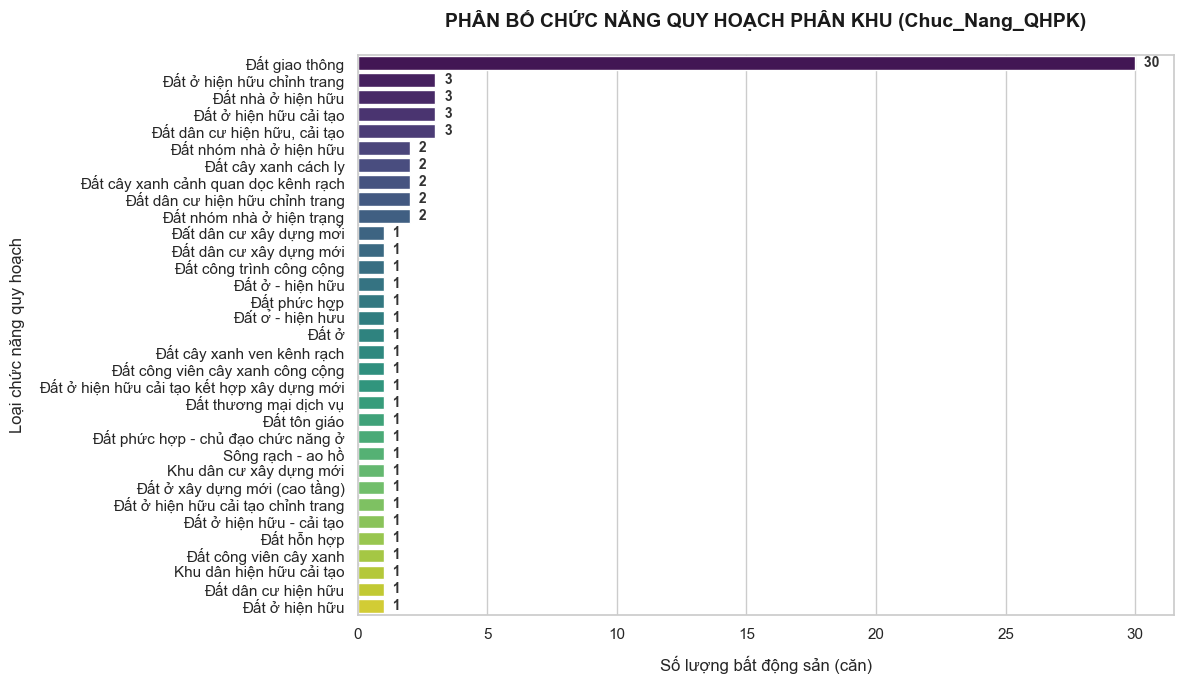

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN FILE TẠI ĐÂY
# ==========================================
FILE_PATH = "new_data_bds1.csv" 
# ==========================================

try:
    # 1. Đọc file CSV với định dạng utf-8-sig để tránh lỗi font tiếng Việt
    df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')

    # Kiểm tra xem cột cần vẽ có tồn tại không
    if 'Chuc_Nang_QHPK' in df.columns:
        
        # 2. Làm sạch dữ liệu: Loại bỏ dòng trống hoặc dòng chưa lấy được thông tin
        df_clean = df[df['Chuc_Nang_QHPK'].notna() & (df['Chuc_Nang_QHPK'].str.strip() != "")]
        
        if df_clean.empty:
            print("⚠️ Cột 'Chuc_Nang_QHPK' không có dữ liệu hợp lệ để vẽ biểu đồ.")
        else:
            # Đếm số lần xuất hiện của từng loại đất và sắp xếp từ nhiều đến ít
            val_counts = df_clean['Chuc_Nang_QHPK'].value_counts()
            
            # 3. Khởi tạo kích thước và giao diện biểu đồ
            plt.figure(figsize=(12, 7))
            sns.set_theme(style="whitegrid")
            
            # Vẽ biểu đồ thanh ngang (Horizontal Bar Plot)
            # Dùng palette 'viridis' hoặc 'crest' để màu sắc tự động phân cấp đẹp mắt
            ax = sns.barplot(x=val_counts.values, y=val_counts.index, palette="viridis", hue=val_counts.index, legend=False)
            
            # 4. Hiển thị số lượng cụ thể ở đầu mỗi thanh
            for i, v in enumerate(val_counts.values):
                ax.text(v + 0.2, i, f" {v}", va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')
            
            # 5. Thiết lập tiêu đề và nhãn các trục
            plt.title("PHÂN BỐ CHỨC NĂNG QUY HOẠCH PHÂN KHU (Chuc_Nang_QHPK)", fontsize=14, fontweight='bold', pad=20, color='#1a1a1a')
            plt.xlabel("Số lượng bất động sản (căn)", fontsize=12, labelpad=10)
            plt.ylabel("Loại chức năng quy hoạch", fontsize=12, labelpad=10)
            
            # Tối ưu khoảng cách hiển thị không bị mất chữ
            plt.tight_layout()
            
            # Hiển thị biểu đồ
            plt.show()
    else:
        print(f"❌ Không tìm thấy cột 'Chuc_Nang_QHPK' trong file '{FILE_PATH}'.")

except FileNotFoundError:
    print(f"❌ Không tìm thấy file '{FILE_PATH}'. Vui lòng chạy lại script cào dữ liệu trước.")
except Exception as e:
    print(f"❌ Có lỗi xảy ra khi vẽ biểu đồ: {e}")

In [ ]:
import requests
import json
import time

# ==========================================
# CẤU HÌNH TOẠ ĐỘ CẦN KIỂM TRA TẠI ĐÂY
# ==========================================
LAT_TEST = 10.79871197   # Thay vĩ độ (Latitude) của bạn vào đây
LON_TEST = 106.6134738  # Thay kinh độ (Longitude) của bạn vào đây

OFFSET_DEGREE = 0.00005 # Khoảng cách dịch chuyển (~5.5 mét)
# ==========================================

def lay_thong_tin_quy_hoach(session, lat, lon):
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    headers = {
        "Host": "sqhkt-qlqh.tphcm.gov.vn",
        "Accept": "application/json, text/plain, */*",
        "Content-Type": "application/x-www-form-urlencoded",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
        "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
    }
    data = {"Lat": str(lat), "Lon": str(lon)}
    
    ket_qua = {
        "Quan_Huyen": "", "Phuong_Xa": "", "Dien_Tich": "",
        "Chuc_Nang_QHPK": "", "Ten_Do_An": "", "Trang_Thai": "Thành công"
    }

    so_lan_thu_toi_da = 3
    for lan_thu in range(1, so_lan_thu_toi_da + 1):
        try:
            response = session.post(url, headers=headers, data=data, timeout=20)
            response.raise_for_status()
            result = response.json()
            
            if result.get("blocked") == 1:
                ket_qua["Trang_Thai"] = "Bị chặn IP"
                return ket_qua

            # 1. Bóc tách Thông tin chung
            if "ThongTinChung" in result and result["ThongTinChung"] not in ("[]", "{}"):
                try:
                    thong_tin_chung = json.loads(result["ThongTinChung"])
                    ket_qua["Quan_Huyen"] = thong_tin_chung.get("tenquanhuyen", "")
                    ket_qua["Phuong_Xa"] = thong_tin_chung.get("tenphuongxa", "")
                    ket_qua["Dien_Tich"] = thong_tin_chung.get("dientich", "")
                    if "dsdoan" in thong_tin_chung and isinstance(thong_tin_chung["dsdoan"], list):
                        ket_qua["Ten_Do_An"] = " | ".join(thong_tin_chung["dsdoan"])
                except json.JSONDecodeError:
                    ket_qua["Trang_Thai"] = "Lỗi parse JSON Thông Tin Chung"

            # 2. Bóc tách Quy hoạch phân khu
            if "QHPK" in result and result["QHPK"] not in ("[]", "{}"):
                try:
                    qhpk = json.loads(result["QHPK"])
                    if len(qhpk) > 0:
                        props = qhpk[0].get("properties", {})
                        ket_qua["Chuc_Nang_QHPK"] = props.get("chucnang", "")
                except json.JSONDecodeError:
                     ket_qua["Trang_Thai"] = "Lỗi parse JSON QHPK"
            break

        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError):
            if lan_thu < so_lan_thu_toi_da:
                time.sleep(lan_thu * 3)
            else:
                ket_qua["Trang_Thai"] = f"Lỗi mạng/API (Đã thử {so_lan_thu_toi_da} lần không thành công)"
        except Exception as e:
            ket_qua["Trang_Thai"] = f"Lỗi hệ thống: {e}"
            break

    return ket_qua

def lay_thong_tin_quy_hoach_thong_minh(session, lat, lon):
    danh_sach_diem_quet = [
        (0, 0),
        (OFFSET_DEGREE, 0), (-OFFSET_DEGREE, 0), (0, OFFSET_DEGREE), (0, -OFFSET_DEGREE),
        (OFFSET_DEGREE, OFFSET_DEGREE), (-OFFSET_DEGREE, -OFFSET_DEGREE), 
        (OFFSET_DEGREE, -OFFSET_DEGREE), (-OFFSET_DEGREE, OFFSET_DEGREE)
    ]
    ket_qua_tam = None
    
    for idx, (d_lat, d_lon) in enumerate(danh_sach_diem_quet):
        cur_lat = lat + d_lat
        cur_lon = lon + d_lon
        
        if d_lat != 0 or d_lon != 0:
            print(f"   → Điểm gốc dính đất giao thông. Đang quét điểm lân cận thứ {idx}...")
            time.sleep(1.5) 
            
        ket_qua = lay_thong_tin_quy_hoach(session, cur_lat, cur_lon)
        trang_thai = ket_qua.get("Trang_Thai", "")
        chuc_nang_lower = ket_qua.get("Chuc_Nang_QHPK", "").lower()
        
        if "Lỗi mạng/API" in trang_thai or "Bị chặn IP" in trang_thai:
            return ket_qua if (d_lat == 0 and d_lon == 0) else ket_qua_tam
        
        if d_lat == 0 and d_lon == 0:
            ket_qua_tam = ket_qua
            if "giao thông" not in chuc_nang_lower and "Thành công" in trang_thai:
                return ket_qua_tam
        else:
            if chuc_nang_lower and "giao thông" not in chuc_nang_lower:
                ket_qua["Trang_Thai"] = "Thành công (Đã tự động dịch chuyển điểm để né đất giao thông)"
                return ket_qua
                
    return ket_qua_tam

# --- CHẠY THỬ NGHIỆM ---
if __name__ == "__main__":
    print(f"🚀 Bắt đầu truy vấn tọa độ: {LAT_TEST}, {LON_TEST}...")
    
    with requests.Session() as đi_cho_api:
        thong_tin_dat = lay_thong_tin_quy_hoach_thong_minh(đi_cho_api, LAT_TEST, LON_TEST)
        
    print("\n📊 KẾT QUẢ TRẢ VỀ:")
    print("-" * 50)
    print(f"📍 Quận/Huyện       : {thong_tin_dat['Quan_Huyen']}")
    print(f"📍 Phường/Xã        : {thong_tin_dat['Phuong_Xa']}")
    print(f"📐 Diện tích ô đất   : {thong_tin_dat['Dien_Tich']} m²")
    print(f"🏗️ Chức năng QHPK   : {thong_tin_dat['Chuc_Nang_QHPK']}")
    print(f"🗺️ Tên đồ án         : {thong_tin_dat['Ten_Do_An']}")
    print(f"🟢 Trạng thái xử lý : {thong_tin_dat['Trang_Thai']}")
    print("-" * 50)

🚀 Bắt đầu truy vấn tọa độ: 10.79871197, 106.6134738...

📊 KẾT QUẢ TRẢ VỀ:
--------------------------------------------------
📍 Quận/Huyện       : Quận Tân Phú
📍 Phường/Xã        : Phường Sơn Kỳ
📐 Diện tích ô đất   : 40.0000000000 m²
🏗️ Chức năng QHPK   : Đất nhóm nhà ở hiện hữu chỉnh trang
🗺️ Tên đồ án         : Đồ án quy hoạch phân khu tỷ lệ 1/2000 Khu 1, Quận Tân Phú (quy hoạch sử dụng đất, kiến trúc, giao thông)
🟢 Trạng thái xử lý : Thành công
--------------------------------------------------


In [ ]:
import requests
import json
import time

# ==========================================
# CẤU HÌNH TOẠ ĐỘ CẦN KIỂM TRA TẠI ĐÂY
# ==========================================
LAT_TEST = 10.79871197   # Thay vĩ độ (Latitude) của bạn vào đây
LON_TEST = 106.6134738
# ==========================================

def kiem_tra_chi_tiet_quy_hoach(lat, lon):
    url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    headers = {
        "Host": "sqhkt-qlqh.tphcm.gov.vn",
        "Accept": "application/json, text/plain, */*",
        "Content-Type": "application/x-www-form-urlencoded",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
        "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
    }
    data = {"Lat": str(lat), "Lon": str(lon)}
    
    try:
        with requests.Session() as session:
            response = session.post(url, headers=headers, data=data, timeout=20)
            response.raise_for_status()
            res_json = response.json()
            
            print(f"🚀 Truy vấn tọa độ: {lat}, {lon}")
            print("=" * 60)
            
            # Kiểm tra và giải mã QHPK
            qhpk_raw = res_json.get("QHPK", "[]")
            if isinstance(qhpk_raw, str):
                qhpk_data = json.loads(qhpk_raw)
            else:
                qhpk_data = qhpk_raw
                
            if not qhpk_data:
                print("❌ Không tìm thấy dữ liệu Quy hoạch phân khu (QHPK) tại tọa độ này.")
                return

            print(f"📌 Tìm thấy {len(qhpk_data)} phân khu quy hoạch chồng lấn/liên quan:")
            print("-" * 60)
            
            for idx, phan_khu in enumerate(qhpk_data, 1):
                props = phan_khu.get("properties", {})
                
                # Trích xuất các trường đặc trưng thường có trong core GIS của Sở
                chuc_nang = props.get("chucnang") or props.get("CHUCNANG") or "Không có dữ liệu"
                tang_cao = props.get("tangcao") or props.get("TANGCAO") or props.get("tangcao_td") or "Không có dữ liệu"
                mat_do = props.get("matdo") or props.get("MATDO") or props.get("mdxd") or "Không có dữ liệu"
                he_so = props.get("heso") or props.get("HESO") or props.get("hssdd") or "Không có dữ liệu"
                ma_do_an = props.get("madoan") or props.get("MADOAN") or "Không rõ"
                
                print(f"Phân khu thứ {idx}:")
                print(f"  🔹 Chức năng quy hoạch : {chuc_nang}")
                print(f"  🔹 Tầng cao xây dựng  : {tang_cao}")
                print(f"  🔹 Mật độ xây dựng   : {mat_do}")
                print(f"  🔹 Hệ số sử dụng đất  : {he_so}")
                print(f"  🗺️ Mã đồ án liên quan  : {ma_do_an}")
                print("-" * 60)
                
            # Kiểm tra xem có dữ liệu lộ giới hẻm hay không
            logio_raw = res_json.get("LoGioi", "[]")
            logio_data = json.loads(logio_raw) if isinstance(logio_raw, str) else logio_raw
            if logio_data:
                print(f"🚧 PHÁT HIỆN THÔNG TIN LỘ GIỚI CHI TIẾT (LoGioi): {len(logio_data)} bản ghi")
                print(json.dumps(logio_data, indent=2, ensure_ascii=False))
            else:
                print("🚧 Lộ giới chi tiết (LoGioi): Không dính hoặc không có dữ liệu riêng lẻ.")

    except Exception as e:
        print(f"❌ Có lỗi xảy ra: {e}")

# Chạy kiểm tra
if __name__ == "__main__":
    kiem_tra_chi_tiet_quy_hoach(LAT_TEST, LON_TEST)

🚀 Truy vấn tọa độ: 10.79871197, 106.6134738
📌 Tìm thấy 1 phân khu quy hoạch chồng lấn/liên quan:
------------------------------------------------------------
Phân khu thứ 1:
  🔹 Chức năng quy hoạch : Đất nhóm nhà ở hiện hữu chỉnh trang
  🔹 Tầng cao xây dựng  : Không có dữ liệu
  🔹 Mật độ xây dựng   : Không có dữ liệu
  🔹 Hệ số sử dụng đất  : Không có dữ liệu
  🗺️ Mã đồ án liên quan  : Không rõ
------------------------------------------------------------
🚧 Lộ giới chi tiết (LoGioi): Không dính hoặc không có dữ liệu riêng lẻ.


In [ ]:
import requests
import json

# ==========================================
# CẤU HÌNH TOẠ ĐỘ CẦN SOI GÓI TIN TẠI ĐÂY
# ==========================================
LAT_TEST = 10.79871197   # Thay vĩ độ (Latitude) của bạn vào đây
LON_TEST = 106.6134738
# ==========================================

url = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
headers = {
    "Host": "sqhkt-qlqh.tphcm.gov.vn",
    "Accept": "application/json, text/plain, */*",
    "Content-Type": "application/x-www-form-urlencoded",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    "Origin": "https://thongtinquyhoach.hochiminhcity.gov.vn",
    "Referer": "https://thongtinquyhoach.hochiminhcity.gov.vn/"
}
data = {"Lat": str(LAT_TEST), "Lon": str(LON_TEST)}

try:
    print(f"📡 Đang kết nối và tải toàn bộ gói tin tại tọa độ ({LAT_TEST}, {LON_TEST})...")
    response = requests.post(url, headers=headers, data=data, timeout=25)
    response.raise_for_status()
    
    # Gói tin thô tầng 1 từ máy chủ
    goi_tin_raw = response.json()
    
    # ĐIỂM QUAN TRỌNG: Quét và bẻ khóa toàn bộ các chuỗi JSON lồng nhau (Stringified JSON)
    for khoa, gia_tri in goi_tin_raw.items():
        if isinstance(gia_tri, str) and (gia_tri.startswith("{") or gia_tri.startswith("[")):
            try:
                # Ép chuỗi văn bản thành cấu trúc Dict/List thực sự trong Python
                goi_tin_raw[khoa] = json.loads(gia_tri)
            except json.JSONDecodeError:
                pass 

    # 1. In ra toàn bộ trên màn hình Console (Không giới hạn ký tự)
    print("\n🔍 --- TOÀN BỘ NỘI DUNG GÓI TIN TRẢ VỀ TỪ WEB ---")
    print(json.dumps(goi_tin_raw, indent=4, ensure_ascii=False))
    print("------------------------------------------------\n")
    
    # 2. Đồng thời lưu ra file JSON để bạn mở bằng text editor xem cho sướng mắt
    file_output = "goi_tin_goc.json"
    with open(file_output, "w", encoding="utf-8") as f:
        json.dump(goi_tin_raw, f, indent=4, ensure_ascii=False)
        
    print(f"💾 Đã lưu thành công 100% dữ liệu không cắt bớt vào file: '{file_output}'")
    print("👉 Hãy mở file này lên để kiểm tra chi tiết các mảng QHPK, CTXD, LoGioi nhé!")

except requests.exceptions.RequestException as e:
    print(f"❌ Lỗi kết nối mạng hoặc API sập: {e}")
except Exception as e:
    print(f"❌ Lỗi xử lý dữ liệu: {e}")

📡 Đang kết nối và tải toàn bộ gói tin tại tọa độ (10.79871197, 106.6134738)...


KeyboardInterrupt: 

# Phát hiện vấn đề một toạ độ trả về thông tin của một ô đất chứa nó. Thông tin đó bao gồm nhiều loại đất quy hoạch và diện tích theo loại. 

# Crawl đầy đủ thông tin hơn.

In [ ]:
import ast
import csv
import json
import time
import requests

# ==========================================
# CẤU HÌNH TẠI ĐÂY
# ==========================================
FILE_INPUT       = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Bản_ghi_chỉ_có_trong_bds.csv"
FILE_OUTPUT      = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Bản_ghi_chỉ_có_trong_bds_quyhoach.csv"
MAX_RETRY        = 3
BACKOFF_FACTOR   = 3
DELAY_GIUA_DONG  = 1        # giây nghỉ giữa các dòng
OFFSET_DEGREE    = 0.00005  # ~5.5m — dùng khi điểm gốc chỉ có đất giao thông
# ==========================================

session = requests.Session()
session.headers.update({
    "Host":         "sqhkt-qlqh.tphcm.gov.vn",
    "Accept":       "application/json, text/plain, */*",
    "Content-Type": "application/x-www-form-urlencoded",
    "User-Agent":   "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
    "Origin":       "https://thongtinquyhoach.hochiminhcity.gov.vn",
    "Referer":      "https://thongtinquyhoach.hochiminhcity.gov.vn/"
})

# ==============================================================
# CẤU TRÚC CÁC CỘT ĐẦU RA
#
# Với lô đất có nhiều ô quy hoạch, mỗi trường QHPK gộp
# tất cả các giá trị lại bằng dấu " | " theo thứ tự ô.
#
# Ví dụ lô có 2 ô:
#   QHPK_Chuc_Nang = "Đất giao thông | Đất nhóm ở hiện trạng..."
#   QHPK_Dien_Tich = "1759.32 | 1566.05"
#   QHPK_Ty_Le     = "48.87% | 43.50%"
#   QHPK_Ma_QU     = "DGT | NNO"
#   QHPK_Ma_O_Pho  = " | II-12"
#   QHPK_So_O      = 2
# ==============================================================
CAC_COT_MOI = [
    "Quan_Huyen",
    "Phuong_Xa",
    "So_Thua",
    "So_To",
    "Dien_Tich_Lo",
    "Ten_Do_An",
    "QHPK_So_O",        # Số ô quy hoạch trả về
    "QHPK_Chuc_Nang",   # Tên chức năng, gộp bằng " | "
    "QHPK_Dien_Tich",   # Diện tích từng ô (m²), gộp bằng " | "
    "QHPK_Ty_Le",       # % diện tích từng ô, gộp bằng " | "
    "QHPK_Ma_QU",       # Mã quy ước (maquyuoc), gộp bằng " | "
    "QHPK_Ma_O_Pho",    # Mã ô phố (maopho), gộp bằng " | "
    "Trang_Thai",
]

SEP = " | "  # Dấu phân cách giữa các ô trong cùng 1 cột


# ──────────────────────────────────────────────────────────────
def _goi_api_mot_diem(lat, lon):
    """
    Gọi API cho 1 tọa độ. Trả về (result_data, None) nếu thành công,
    hoặc (None, "thông báo lỗi") nếu thất bại.
    """
    url  = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    data = {"Lat": lat, "Lon": lon}

    for attempt in range(1, MAX_RETRY + 1):
        try:
            if attempt > 1:
                time.sleep(BACKOFF_FACTOR * (attempt - 1))

            response = session.post(url, data=data, timeout=15)

            if response.status_code != 200:
                return None, f"Lỗi HTTP {response.status_code}"

            raw_text = response.text.strip() if response.text else ""
            if not raw_text:
                return None, "Server trả về rỗng"

            # Parse JSON — fallback sang ast nếu server dùng nháy đơn
            try:
                result_data = response.json()
            except (json.JSONDecodeError, ValueError):
                try:
                    result_data = ast.literal_eval(raw_text)
                except Exception:
                    return None, f"Lỗi cấu trúc dữ liệu: {raw_text[:50]}"

            if isinstance(result_data, dict) and "error" in result_data:
                return None, f"Bị khóa: {result_data['error']}"
            if result_data.get("blocked") == 1:
                return None, "Bị chặn IP"

            return result_data, None  # ✅ thành công

        except requests.exceptions.Timeout:
            if attempt == MAX_RETRY:
                return None, "Mạng Timeout (Hết lượt thử lại)"
        except requests.exceptions.RequestException as e:
            if attempt == MAX_RETRY:
                return None, f"Lỗi mạng: {str(e)[:50]}"
        except Exception as e:
            return None, f"Lỗi không xác định: {str(e)[:50]}"

    return None, "Hết lượt retry"


def _boc_tach_ket_qua(result_data):
    """
    Chuyển dict raw từ API → dict kết quả theo CAC_COT_MOI.
    Các trường QHPK gộp nhiều ô bằng SEP = ' | '.
    """
    kq = {c: "" for c in CAC_COT_MOI}
    kq["QHPK_So_O"] = 0
    kq["Trang_Thai"] = "Thành công"

    # ── 1. ThongTinChung ────────────────────────────────────
    raw_chung = result_data.get("ThongTinChung", "")
    if raw_chung and raw_chung not in ("[]", "{}"):
        try:
            ttc = json.loads(raw_chung) if isinstance(raw_chung, str) else raw_chung
            if isinstance(ttc, dict):
                kq["Quan_Huyen"]   = ttc.get("tenquanhuyen", "")
                kq["Phuong_Xa"]    = ttc.get("tenphuongxa", "")
                kq["So_Thua"]      = ttc.get("sothua", "")
                kq["So_To"]        = ttc.get("soto", "")
                kq["Dien_Tich_Lo"] = ttc.get("dientich", "")
                dsdoan = ttc.get("dsdoan", [])
                if isinstance(dsdoan, list):
                    kq["Ten_Do_An"] = SEP.join(dsdoan)
        except Exception:
            kq["Trang_Thai"] = "Lỗi bóc tách ThongTinChung"

    # ── 2. QHPK — lấy TẤT CẢ ô, gộp thành 1 chuỗi ─────────
    raw_qhpk = result_data.get("QHPK", "")
    if raw_qhpk and raw_qhpk not in ("[]", "{}"):
        try:
            qhpk_list = json.loads(raw_qhpk) if isinstance(raw_qhpk, str) else raw_qhpk

            # Chuẩn hoá về list dù server trả object đơn
            if isinstance(qhpk_list, dict):
                qhpk_list = [qhpk_list]

            if isinstance(qhpk_list, list) and len(qhpk_list) > 0:
                ds_chuc_nang = []
                ds_dien_tich = []
                ds_ty_le     = []
                ds_ma_qu     = []
                ds_ma_o_pho  = []

                for item in qhpk_list:
                    props = item.get("properties", {}) if isinstance(item, dict) else {}

                    chuc_nang = props.get("chucnang") or props.get("chucNang") or ""
                    dien_tich = props.get("dientich", "")
                    ty_le     = props.get("tldientich", "")
                    ma_qu     = props.get("maquyuoc", "") or ""
                    ma_o_pho  = props.get("maopho", "")   or ""

                    # Làm tròn 2 chữ số thập phân
                    try:
                        dien_tich = f"{float(dien_tich):.2f}"
                    except (TypeError, ValueError):
                        dien_tich = str(dien_tich)

                    try:
                        ty_le = f"{float(ty_le):.2f}%"
                    except (TypeError, ValueError):
                        ty_le = str(ty_le)

                    ds_chuc_nang.append(chuc_nang)
                    ds_dien_tich.append(dien_tich)
                    ds_ty_le.append(ty_le)
                    ds_ma_qu.append(str(ma_qu))
                    ds_ma_o_pho.append(str(ma_o_pho))

                kq["QHPK_So_O"]      = len(qhpk_list)
                kq["QHPK_Chuc_Nang"] = SEP.join(ds_chuc_nang)
                kq["QHPK_Dien_Tich"] = SEP.join(ds_dien_tich)
                kq["QHPK_Ty_Le"]     = SEP.join(ds_ty_le)
                kq["QHPK_Ma_QU"]     = SEP.join(ds_ma_qu)
                kq["QHPK_Ma_O_Pho"]  = SEP.join(ds_ma_o_pho)

        except Exception as e:
            kq["Trang_Thai"] = f"Lỗi bóc tách QHPK: {str(e)[:60]}"

    return kq


def lay_thong_tin_quy_hoach(lat, lon):
    """
    Hàm chính: gọi API tại tọa độ gốc.
    Nếu kết quả CHỈ có đất giao thông → thử 8 điểm lân cận (~5.5m)
    để tìm ô đất có chức năng khác.
    """
    cac_diem = [
        (0, 0),
        ( OFFSET_DEGREE,  0),             (-OFFSET_DEGREE,  0),
        (0,               OFFSET_DEGREE), (0,              -OFFSET_DEGREE),
        ( OFFSET_DEGREE,  OFFSET_DEGREE), (-OFFSET_DEGREE, -OFFSET_DEGREE),
        ( OFFSET_DEGREE, -OFFSET_DEGREE), (-OFFSET_DEGREE,  OFFSET_DEGREE),
    ]
    ket_qua_goc = None

    for idx, (d_lat, d_lon) in enumerate(cac_diem):
        if d_lat != 0 or d_lon != 0:
            time.sleep(1.5)

        result_data, loi = _goi_api_mot_diem(float(lat) + d_lat, float(lon) + d_lon)

        # Lỗi nghiêm trọng → dừng
        if loi and any(k in loi for k in ("Bị chặn", "Timeout", "Lỗi mạng")):
            kq = {c: "" for c in CAC_COT_MOI}
            kq["Trang_Thai"] = loi
            return ket_qua_goc or kq

        if loi:
            kq = {c: "" for c in CAC_COT_MOI}
            kq["Trang_Thai"] = loi
            if d_lat == 0 and d_lon == 0:
                ket_qua_goc = kq
            continue

        kq = _boc_tach_ket_qua(result_data)

        # Kiểm tra có ô nào KHÔNG phải giao thông không
        cac_o = [o.strip().lower() for o in kq["QHPK_Chuc_Nang"].split("|")]
        co_o_khac = any("giao thông" not in o for o in cac_o if o)

        if d_lat == 0 and d_lon == 0:
            ket_qua_goc = kq
            if co_o_khac or not kq["QHPK_Chuc_Nang"]:
                return kq  # Điểm gốc đã có ô không phải GT → dùng luôn
            # Toàn giao thông → tiếp tục thử điểm lân cận
        else:
            if co_o_khac:
                kq["Trang_Thai"] = "Thành công (Tự động dịch điểm, điểm gốc chỉ có đất giao thông)"
                return kq

    return ket_qua_goc  # Trả kết quả gốc dù toàn giao thông


# ──────────────────────────────────────────────────────────────
def xu_ly_file_csv(file_dau_vao, file_dau_ra):
    try:
        # Đọc header file input
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f:
            cac_cot_goc = csv.DictReader(f).fieldnames

        if not cac_cot_goc or 'Latitude' not in cac_cot_goc or 'Longitude' not in cac_cot_goc:
            print("❌ File CSV đầu vào phải có cột 'Latitude' và 'Longitude'.")
            return

        # Đếm tổng số dòng
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f:
            tong_dong = len(list(csv.DictReader(f)))

        toan_bo_cot = cac_cot_goc + CAC_COT_MOI

        print(f"🚀 Bắt đầu xử lý {tong_dong} dòng...\n")
        print(f"   Các ô QHPK gộp bằng dấu ' | ' nếu có nhiều ô.\n")

        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f_in, \
             open(file_dau_ra,  mode='w', encoding='utf-8-sig', newline='') as f_out:

            reader = csv.DictReader(f_in)
            writer = csv.DictWriter(f_out, fieldnames=toan_bo_cot)
            writer.writeheader()

            for index, row in enumerate(reader, 1):
                link = row.get("Link", "N/A")
                lat  = row.get("Latitude",  "").strip()
                lon  = row.get("Longitude", "").strip()

                print(f"[{index}/{tong_dong}] {link[:45]}... | Tọa độ: {lat}, {lon}")

                if lat and lon:
                    thong_tin = lay_thong_tin_quy_hoach(lat, lon)
                    row.update(thong_tin)

                    # In tóm tắt ra terminal
                    so_o      = thong_tin.get("QHPK_So_O", 0)
                    chuc_nang = thong_tin.get("QHPK_Chuc_Nang", "")
                    ty_le     = thong_tin.get("QHPK_Ty_Le", "")
                    trang_thai = thong_tin.get("Trang_Thai", "")
                    print(f"   ✔ {so_o} ô  |  {chuc_nang}")
                    print(f"   ✔ Tỷ lệ: {ty_le}  |  {trang_thai}")
                else:
                    row["Trang_Thai"] = "Thiếu tọa độ"
                    print(f"   ⚠️  Bỏ qua — thiếu tọa độ")

                writer.writerow(row)
                time.sleep(DELAY_GIUA_DONG)

        print(f"\n✅ Hoàn tất! File kết quả: {file_dau_ra}")
        print(f"\n📋 Ý nghĩa các cột QHPK:")
        print(f"   QHPK_So_O       — Số ô quy hoạch")
        print(f"   QHPK_Chuc_Nang  — Chức năng sử dụng đất từng ô")
        print(f"   QHPK_Dien_Tich  — Diện tích từng ô (m²)")
        print(f"   QHPK_Ty_Le      — % diện tích từng ô trong lô")
        print(f"   QHPK_Ma_QU      — Mã quy ước từng ô")
        print(f"   QHPK_Ma_O_Pho   — Mã ô phố từng ô")
        print(f"   (Các ô phân cách bằng ' | ', theo đúng thứ tự)")

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'.")
    except Exception as e:
        print(f"❌ Lỗi nghiêm trọng: {e}")

In [ ]:
if __name__ == "__main__":
    xu_ly_file_csv(FILE_INPUT, FILE_OUTPUT)

🚀 Bắt đầu xử lý 831 dòng...

   Các ô QHPK gộp bằng dấu ' | ' nếu có nhiều ô.

[1/831] https://batdongsan.com.vn/ban-nha-rieng-duong... | Tọa độ: 10.764640163967105, 106.69220041593972
   ✔ 4 ô  |  Đất công trình công cộng (thương mại dịch vụ) | Đất giao thông | Đất giao thông | Đất giao thông
   ✔ Tỷ lệ: 1.85% | 1.29% | 96.19% | 0.67%  |  Thành công
[2/831] https://batdongsan.com.vn/ban-nha-rieng-duong... | Tọa độ: 10.8528630209991, 106.720374186852
   ✔  ô  |  
   ✔ Tỷ lệ:   |  Bị khóa: The land is temporarily locked!
[3/831] https://batdongsan.com.vn/ban-nha-rieng-duong... | Tọa độ: 10.8000280460014, 106.650704397356
   ✔ 3 ô  |  Đất ở - hiện hữu | Đất ở - hiện hữu | Đất giao thông
   ✔ Tỷ lệ: 4.15% | 3.33% | 92.52%  |  Thành công
[4/831] https://batdongsan.com.vn/ban-nha-mat-pho-duo... | Tọa độ: 10.7932583037954, 106.640202947743
   ✔ 3 ô  |  Đất ở - hiện hữu | Đất giao thông | Đất cây xanh công viên - thể dục thể thao
   ✔ Tỷ lệ: 16.93% | 81.01% | 2.06%  |  Thành công
[5/831] http

# Chạy lại những bản ghi bị thu lỗi (thử nghiệm cho thấy chỉ thành công với những lỗi đường truyền, lỗi server thì không)

In [ ]:
import csv
import time
import requests
import json
import ast

# ==========================================
# CẤU HÌNH TẠI ĐÂY
# ==========================================
FILE_INPUT       = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Bản_ghi_chỉ_có_trong_bds.csv"
FILE_OUTPUT      = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Bản_ghi_chỉ_có_trong_bds_quyhoach.csv"
MAX_RETRY        = 3
BACKOFF_FACTOR   = 3
DELAY_GIUA_DONG  = 3
OFFSET_DEGREE    = 0.00005

# Một bản ghi bị coi là "cần chạy lại" nếu thoả MỘT TRONG CÁC điều kiện sau:
# 1. Cột Trang_Thai chứa từ khoá lỗi
# 2. Cột Quan_Huyen bị trống (lấy được tọa độ nhưng không trả về dữ liệu)
CAC_TU_KHOA_LOI = [
    "timeout", "lỗi", "mạng", "chặn", "rỗng",
    "retry", "không xác định", "http", "bị khóa"
]
# ==========================================

session = requests.Session()
session.headers.update({
    "Host":         "sqhkt-qlqh.tphcm.gov.vn",
    "Accept":       "application/json, text/plain, */*",
    "Content-Type": "application/x-www-form-urlencoded",
    "User-Agent":   "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
    "Origin":       "https://thongtinquyhoach.hochiminhcity.gov.vn",
    "Referer":      "https://thongtinquyhoach.hochiminhcity.gov.vn/"
})

SEP = " | "

CAC_COT_QHPK = [
    "Quan_Huyen", "Phuong_Xa", "So_Thua", "So_To", "Dien_Tich_Lo", "Ten_Do_An",
    "QHPK_So_O", "QHPK_Chuc_Nang", "QHPK_Dien_Tich", "QHPK_Ty_Le",
    "QHPK_Ma_QU", "QHPK_Ma_O_Pho", "Trang_Thai",
]


# ──────────────────────────────────────────────────────────────
def can_chay_lai(row):
    """
    Trả về True nếu bản ghi này cần chạy lại.
    Tiêu chí:
      - Trang_Thai chứa từ khoá lỗi, HOẶC
      - Quan_Huyen trống (dữ liệu chưa được điền)
    Bỏ qua nếu thiếu tọa độ (không thể làm gì được).
    """
    lat = row.get("Latitude", "").strip()
    lon = row.get("Longitude", "").strip()
    if not lat or not lon:
        return False  # Thiếu tọa độ → không thể retry

    trang_thai  = row.get("Trang_Thai", "").strip().lower()
    quan_huyen  = row.get("Quan_Huyen", "").strip()

    co_loi = any(kw in trang_thai for kw in CAC_TU_KHOA_LOI)
    chua_co_du_lieu = (quan_huyen == "")

    return co_loi or chua_co_du_lieu


# ── Các hàm API (copy từ thu_thap_quy_hoach.py) ───────────────
def _goi_api_mot_diem(lat, lon):
    url  = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    data = {"Lat": lat, "Lon": lon}

    for attempt in range(1, MAX_RETRY + 1):
        try:
            if attempt > 1:
                time.sleep(BACKOFF_FACTOR * (attempt - 1))

            response = session.post(url, data=data, timeout=15)

            if response.status_code != 200:
                return None, f"Lỗi HTTP {response.status_code}"

            raw_text = response.text.strip() if response.text else ""
            if not raw_text:
                return None, "Server trả về rỗng"

            try:
                result_data = response.json()
            except (json.JSONDecodeError, ValueError):
                try:
                    result_data = ast.literal_eval(raw_text)
                except Exception:
                    return None, f"Lỗi cấu trúc dữ liệu: {raw_text[:50]}"

            if isinstance(result_data, dict) and "error" in result_data:
                return None, f"Bị khóa: {result_data['error']}"
            if result_data.get("blocked") == 1:
                return None, "Bị chặn IP"

            return result_data, None

        except requests.exceptions.Timeout:
            if attempt == MAX_RETRY:
                return None, "Mạng Timeout (Hết lượt thử lại)"
        except requests.exceptions.RequestException as e:
            if attempt == MAX_RETRY:
                return None, f"Lỗi mạng: {str(e)[:50]}"
        except Exception as e:
            return None, f"Lỗi không xác định: {str(e)[:50]}"

    return None, "Hết lượt retry"


def _boc_tach_ket_qua(result_data):
    kq = {c: "" for c in CAC_COT_QHPK}
    kq["QHPK_So_O"] = 0
    kq["Trang_Thai"] = "Thành công"

    raw_chung = result_data.get("ThongTinChung", "")
    if raw_chung and raw_chung not in ("[]", "{}"):
        try:
            ttc = json.loads(raw_chung) if isinstance(raw_chung, str) else raw_chung
            if isinstance(ttc, dict):
                kq["Quan_Huyen"]   = ttc.get("tenquanhuyen", "")
                kq["Phuong_Xa"]    = ttc.get("tenphuongxa", "")
                kq["So_Thua"]      = ttc.get("sothua", "")
                kq["So_To"]        = ttc.get("soto", "")
                kq["Dien_Tich_Lo"] = ttc.get("dientich", "")
                dsdoan = ttc.get("dsdoan", [])
                if isinstance(dsdoan, list):
                    kq["Ten_Do_An"] = SEP.join(dsdoan)
        except Exception:
            kq["Trang_Thai"] = "Lỗi bóc tách ThongTinChung"

    raw_qhpk = result_data.get("QHPK", "")
    if raw_qhpk and raw_qhpk not in ("[]", "{}"):
        try:
            qhpk_list = json.loads(raw_qhpk) if isinstance(raw_qhpk, str) else raw_qhpk
            if isinstance(qhpk_list, dict):
                qhpk_list = [qhpk_list]

            if isinstance(qhpk_list, list) and len(qhpk_list) > 0:
                ds_chuc_nang, ds_dien_tich, ds_ty_le, ds_ma_qu, ds_ma_o_pho = [], [], [], [], []

                for item in qhpk_list:
                    props     = item.get("properties", {}) if isinstance(item, dict) else {}
                    chuc_nang = props.get("chucnang") or props.get("chucNang") or ""
                    dien_tich = props.get("dientich", "")
                    ty_le     = props.get("tldientich", "")
                    ma_qu     = props.get("maquyuoc", "") or ""
                    ma_o_pho  = props.get("maopho", "")   or ""

                    try:
                        dien_tich = f"{float(dien_tich):.2f}"
                    except (TypeError, ValueError):
                        dien_tich = str(dien_tich)
                    try:
                        ty_le = f"{float(ty_le):.2f}%"
                    except (TypeError, ValueError):
                        ty_le = str(ty_le)

                    ds_chuc_nang.append(chuc_nang)
                    ds_dien_tich.append(dien_tich)
                    ds_ty_le.append(ty_le)
                    ds_ma_qu.append(str(ma_qu))
                    ds_ma_o_pho.append(str(ma_o_pho))

                kq["QHPK_So_O"]      = len(qhpk_list)
                kq["QHPK_Chuc_Nang"] = SEP.join(ds_chuc_nang)
                kq["QHPK_Dien_Tich"] = SEP.join(ds_dien_tich)
                kq["QHPK_Ty_Le"]     = SEP.join(ds_ty_le)
                kq["QHPK_Ma_QU"]     = SEP.join(ds_ma_qu)
                kq["QHPK_Ma_O_Pho"]  = SEP.join(ds_ma_o_pho)
        except Exception as e:
            kq["Trang_Thai"] = f"Lỗi bóc tách QHPK: {str(e)[:60]}"

    return kq


def lay_thong_tin_quy_hoach(lat, lon):
    cac_diem = [
        (0, 0),
        ( OFFSET_DEGREE,  0),             (-OFFSET_DEGREE,  0),
        (0,               OFFSET_DEGREE), (0,              -OFFSET_DEGREE),
        ( OFFSET_DEGREE,  OFFSET_DEGREE), (-OFFSET_DEGREE, -OFFSET_DEGREE),
        ( OFFSET_DEGREE, -OFFSET_DEGREE), (-OFFSET_DEGREE,  OFFSET_DEGREE),
    ]
    ket_qua_goc = None

    for idx, (d_lat, d_lon) in enumerate(cac_diem):
        if d_lat != 0 or d_lon != 0:
            time.sleep(1.5)

        result_data, loi = _goi_api_mot_diem(float(lat) + d_lat, float(lon) + d_lon)

        if loi and any(k in loi for k in ("Bị chặn", "Timeout", "Lỗi mạng")):
            kq = {c: "" for c in CAC_COT_QHPK}
            kq["Trang_Thai"] = loi
            return ket_qua_goc or kq

        if loi:
            kq = {c: "" for c in CAC_COT_QHPK}
            kq["Trang_Thai"] = loi
            if d_lat == 0 and d_lon == 0:
                ket_qua_goc = kq
            continue

        kq = _boc_tach_ket_qua(result_data)
        cac_o = [o.strip().lower() for o in kq["QHPK_Chuc_Nang"].split("|")]
        co_o_khac = any("giao thông" not in o for o in cac_o if o)

        if d_lat == 0 and d_lon == 0:
            ket_qua_goc = kq
            if co_o_khac or not kq["QHPK_Chuc_Nang"]:
                return kq
        else:
            if co_o_khac:
                kq["Trang_Thai"] = "Thành công (Tự động dịch điểm, điểm gốc chỉ có đất giao thông)"
                return kq

    return ket_qua_goc


# ──────────────────────────────────────────────────────────────
def chay_lai_ban_ghi_loi(file_dau_vao, file_dau_ra):
    try:
        # Đọc toàn bộ file vào RAM
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f:
            reader   = csv.DictReader(f)
            fieldnames = reader.fieldnames
            tat_ca_dong = list(reader)

        if not fieldnames:
            print("❌ File trống hoặc không đọc được header.")
            return

        # Xác định các dòng cần chạy lại
        chi_so_can_retry = [
            i for i, row in enumerate(tat_ca_dong) if can_chay_lai(row)
        ]

        tong_dong    = len(tat_ca_dong)
        tong_retry   = len(chi_so_can_retry)
        tong_ok      = tong_dong - tong_retry

        print(f"📂 Tổng số bản ghi   : {tong_dong}")
        print(f"✅ Đã có dữ liệu     : {tong_ok}")
        print(f"🔁 Cần chạy lại      : {tong_retry}")

        if tong_retry == 0:
            print("\n🎉 Không có bản ghi nào cần chạy lại. File đã đầy đủ!")
            return

        print(f"\n🚀 Bắt đầu retry {tong_retry} bản ghi...\n")

        thanh_cong = 0
        van_loi    = 0

        for thu_tu, i in enumerate(chi_so_can_retry, 1):
            row  = tat_ca_dong[i]
            lat  = row.get("Latitude",  "").strip()
            lon  = row.get("Longitude", "").strip()
            link = row.get("Link", "N/A")

            trang_thai_cu = row.get("Trang_Thai", "").strip()
            print(f"[{thu_tu}/{tong_retry}] Dòng #{i+1} | {link[:40]}...")
            print(f"   Lỗi cũ : {trang_thai_cu}")

            thong_tin = lay_thong_tin_quy_hoach(lat, lon)
            tat_ca_dong[i].update(thong_tin)

            trang_thai_moi = thong_tin.get("Trang_Thai", "")
            so_o      = thong_tin.get("QHPK_So_O", 0)
            chuc_nang = thong_tin.get("QHPK_Chuc_Nang", "")

            if thong_tin.get("Quan_Huyen", "").strip():
                thanh_cong += 1
                print(f"   ✔ Thành công | {so_o} ô | {chuc_nang}")
            else:
                van_loi += 1
                print(f"   ✘ Vẫn lỗi   | {trang_thai_moi}")

            time.sleep(DELAY_GIUA_DONG)

        # Ghi lại toàn bộ file (kể cả dòng không retry, giữ nguyên)
        with open(file_dau_ra, mode='w', encoding='utf-8-sig', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(tat_ca_dong)

        print(f"\n{'='*50}")
        print(f"✅ Retry hoàn tất! File đã lưu: {file_dau_ra}")
        print(f"   Thành công thêm : {thanh_cong} bản ghi")
        print(f"   Vẫn còn lỗi    : {van_loi} bản ghi")
        if van_loi > 0:
            print(f"   → Chạy lại script này thêm lần nữa để retry tiếp.")

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'.")
    except Exception as e:
        print(f"❌ Lỗi nghiêm trọng: {e}")


if __name__ == "__main__":
    chay_lai_ban_ghi_loi(FILE_INPUT, FILE_OUTPUT)

❌ Không tìm thấy file '/data/raw_bds_data.csv'.


Tăng hiệu suất bẳng cách bỏ qua những bản ghi không thể sửa.

In [17]:
import csv
import time
import requests
import json
import ast

# ==========================================
# CẤU HÌNH TẠI ĐÂY
# ==========================================
FILE_INPUT       = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Bản_ghi_chỉ_có_trong_bds_quyhoach.csv"
FILE_OUTPUT      = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Bản_ghi_chỉ_có_trong_bds_quyhoach.csv"
MAX_RETRY        = 3
BACKOFF_FACTOR   = 3
DELAY_GIUA_DONG  = 3
OFFSET_DEGREE    = 0.00005

# Các trạng thái KHÔNG retry dù dữ liệu trống
# (lỗi do bản chất dữ liệu, retry cũng vô ích)
TRANG_THAI_BO_QUA = [
    "server trả về rỗng",
    "bị khóa: the land is temporarily locked!",
]
# ==========================================

session = requests.Session()
session.headers.update({
    "Host":         "sqhkt-qlqh.tphcm.gov.vn",
    "Accept":       "application/json, text/plain, */*",
    "Content-Type": "application/x-www-form-urlencoded",
    "User-Agent":   "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36",
    "Origin":       "https://thongtinquyhoach.hochiminhcity.gov.vn",
    "Referer":      "https://thongtinquyhoach.hochiminhcity.gov.vn/"
})

SEP = " | "

CAC_COT_QHPK = [
    "Quan_Huyen", "Phuong_Xa", "So_Thua", "So_To", "Dien_Tich_Lo", "Ten_Do_An",
    "QHPK_So_O", "QHPK_Chuc_Nang", "QHPK_Dien_Tich", "QHPK_Ty_Le",
    "QHPK_Ma_QU", "QHPK_Ma_O_Pho", "Trang_Thai",
]


# ──────────────────────────────────────────────────────────────
def can_chay_lai(row):
    """
    Trả về True nếu bản ghi cần chạy lại.
    Tiêu chí: Quan_Huyen trống VÀ Trang_Thai không thuộc danh sách bỏ qua.
    """
    lat = row.get("Latitude", "").strip()
    lon = row.get("Longitude", "").strip()
    if not lat or not lon:
        return False  # Thiếu tọa độ

    quan_huyen = row.get("Quan_Huyen", "").strip()
    if quan_huyen:
        return False  # Đã có dữ liệu

    trang_thai = row.get("Trang_Thai", "").strip().lower()
    la_bo_qua  = any(tt in trang_thai for tt in TRANG_THAI_BO_QUA)
    return not la_bo_qua


# ── Các hàm API (copy từ thu_thap_quy_hoach.py) ───────────────
def _goi_api_mot_diem(lat, lon):
    url  = "https://sqhkt-qlqh.tphcm.gov.vn/computing/930/api/v3.1/a-z/all"
    data = {"Lat": lat, "Lon": lon}

    for attempt in range(1, MAX_RETRY + 1):
        try:
            if attempt > 1:
                time.sleep(BACKOFF_FACTOR * (attempt - 1))

            response = session.post(url, data=data, timeout=15)

            if response.status_code != 200:
                return None, f"Lỗi HTTP {response.status_code}"

            raw_text = response.text.strip() if response.text else ""
            if not raw_text:
                return None, "Server trả về rỗng"

            try:
                result_data = response.json()
            except (json.JSONDecodeError, ValueError):
                try:
                    result_data = ast.literal_eval(raw_text)
                except Exception:
                    return None, f"Lỗi cấu trúc dữ liệu: {raw_text[:50]}"

            if isinstance(result_data, dict) and "error" in result_data:
                return None, f"Bị khóa: {result_data['error']}"
            if result_data.get("blocked") == 1:
                return None, "Bị chặn IP"

            return result_data, None

        except requests.exceptions.Timeout:
            if attempt == MAX_RETRY:
                return None, "Mạng Timeout (Hết lượt thử lại)"
        except requests.exceptions.RequestException as e:
            if attempt == MAX_RETRY:
                return None, f"Lỗi mạng: {str(e)[:50]}"
        except Exception as e:
            return None, f"Lỗi không xác định: {str(e)[:50]}"

    return None, "Hết lượt retry"


def _boc_tach_ket_qua(result_data):
    kq = {c: "" for c in CAC_COT_QHPK}
    kq["QHPK_So_O"] = 0
    kq["Trang_Thai"] = "Thành công"

    raw_chung = result_data.get("ThongTinChung", "")
    if raw_chung and raw_chung not in ("[]", "{}"):
        try:
            ttc = json.loads(raw_chung) if isinstance(raw_chung, str) else raw_chung
            if isinstance(ttc, dict):
                kq["Quan_Huyen"]   = ttc.get("tenquanhuyen", "")
                kq["Phuong_Xa"]    = ttc.get("tenphuongxa", "")
                kq["So_Thua"]      = ttc.get("sothua", "")
                kq["So_To"]        = ttc.get("soto", "")
                kq["Dien_Tich_Lo"] = ttc.get("dientich", "")
                dsdoan = ttc.get("dsdoan", [])
                if isinstance(dsdoan, list):
                    kq["Ten_Do_An"] = SEP.join(dsdoan)
        except Exception:
            kq["Trang_Thai"] = "Lỗi bóc tách ThongTinChung"

    raw_qhpk = result_data.get("QHPK", "")
    if raw_qhpk and raw_qhpk not in ("[]", "{}"):
        try:
            qhpk_list = json.loads(raw_qhpk) if isinstance(raw_qhpk, str) else raw_qhpk
            if isinstance(qhpk_list, dict):
                qhpk_list = [qhpk_list]

            if isinstance(qhpk_list, list) and len(qhpk_list) > 0:
                ds_chuc_nang, ds_dien_tich, ds_ty_le, ds_ma_qu, ds_ma_o_pho = [], [], [], [], []

                for item in qhpk_list:
                    props     = item.get("properties", {}) if isinstance(item, dict) else {}
                    chuc_nang = props.get("chucnang") or props.get("chucNang") or ""
                    dien_tich = props.get("dientich", "")
                    ty_le     = props.get("tldientich", "")
                    ma_qu     = props.get("maquyuoc", "") or ""
                    ma_o_pho  = props.get("maopho", "")   or ""

                    try:
                        dien_tich = f"{float(dien_tich):.2f}"
                    except (TypeError, ValueError):
                        dien_tich = str(dien_tich)
                    try:
                        ty_le = f"{float(ty_le):.2f}%"
                    except (TypeError, ValueError):
                        ty_le = str(ty_le)

                    ds_chuc_nang.append(chuc_nang)
                    ds_dien_tich.append(dien_tich)
                    ds_ty_le.append(ty_le)
                    ds_ma_qu.append(str(ma_qu))
                    ds_ma_o_pho.append(str(ma_o_pho))

                kq["QHPK_So_O"]      = len(qhpk_list)
                kq["QHPK_Chuc_Nang"] = SEP.join(ds_chuc_nang)
                kq["QHPK_Dien_Tich"] = SEP.join(ds_dien_tich)
                kq["QHPK_Ty_Le"]     = SEP.join(ds_ty_le)
                kq["QHPK_Ma_QU"]     = SEP.join(ds_ma_qu)
                kq["QHPK_Ma_O_Pho"]  = SEP.join(ds_ma_o_pho)
        except Exception as e:
            kq["Trang_Thai"] = f"Lỗi bóc tách QHPK: {str(e)[:60]}"

    return kq


def lay_thong_tin_quy_hoach(lat, lon):
    cac_diem = [
        (0, 0),
        ( OFFSET_DEGREE,  0),             (-OFFSET_DEGREE,  0),
        (0,               OFFSET_DEGREE), (0,              -OFFSET_DEGREE),
        ( OFFSET_DEGREE,  OFFSET_DEGREE), (-OFFSET_DEGREE, -OFFSET_DEGREE),
        ( OFFSET_DEGREE, -OFFSET_DEGREE), (-OFFSET_DEGREE,  OFFSET_DEGREE),
    ]
    ket_qua_goc = None

    for idx, (d_lat, d_lon) in enumerate(cac_diem):
        if d_lat != 0 or d_lon != 0:
            time.sleep(1.5)

        result_data, loi = _goi_api_mot_diem(float(lat) + d_lat, float(lon) + d_lon)

        if loi and any(k in loi for k in ("Bị chặn", "Timeout", "Lỗi mạng")):
            kq = {c: "" for c in CAC_COT_QHPK}
            kq["Trang_Thai"] = loi
            return ket_qua_goc or kq

        if loi:
            kq = {c: "" for c in CAC_COT_QHPK}
            kq["Trang_Thai"] = loi
            if d_lat == 0 and d_lon == 0:
                ket_qua_goc = kq
            continue

        kq = _boc_tach_ket_qua(result_data)
        cac_o = [o.strip().lower() for o in kq["QHPK_Chuc_Nang"].split("|")]
        co_o_khac = any("giao thông" not in o for o in cac_o if o)

        if d_lat == 0 and d_lon == 0:
            ket_qua_goc = kq
            if co_o_khac or not kq["QHPK_Chuc_Nang"]:
                return kq
        else:
            if co_o_khac:
                kq["Trang_Thai"] = "Thành công (Tự động dịch điểm, điểm gốc chỉ có đất giao thông)"
                return kq

    return ket_qua_goc


# ──────────────────────────────────────────────────────────────
def chay_lai_ban_ghi_loi(file_dau_vao, file_dau_ra):
    try:
        # Đọc toàn bộ file vào RAM
        with open(file_dau_vao, mode='r', encoding='utf-8-sig') as f:
            reader   = csv.DictReader(f)
            fieldnames = reader.fieldnames
            tat_ca_dong = list(reader)

        if not fieldnames:
            print("❌ File trống hoặc không đọc được header.")
            return

        # Xác định các dòng cần chạy lại
        chi_so_can_retry = [
            i for i, row in enumerate(tat_ca_dong) if can_chay_lai(row)
        ]

        tong_dong    = len(tat_ca_dong)
        tong_retry   = len(chi_so_can_retry)
        tong_ok      = tong_dong - tong_retry

        print(f"📂 Tổng số bản ghi   : {tong_dong}")
        print(f"✅ Đã có dữ liệu     : {tong_ok}")
        print(f"🔁 Cần chạy lại      : {tong_retry}")

        if tong_retry == 0:
            print("\n🎉 Không có bản ghi nào cần chạy lại. File đã đầy đủ!")
            return

        print(f"\n🚀 Bắt đầu retry {tong_retry} bản ghi...\n")

        thanh_cong = 0
        van_loi    = 0

        for thu_tu, i in enumerate(chi_so_can_retry, 1):
            row  = tat_ca_dong[i]
            lat  = row.get("Latitude",  "").strip()
            lon  = row.get("Longitude", "").strip()
            link = row.get("Link", "N/A")

            trang_thai_cu = row.get("Trang_Thai", "").strip()
            print(f"[{thu_tu}/{tong_retry}] Dòng #{i+1} | {link[:40]}...")
            print(f"   Lỗi cũ : {trang_thai_cu}")

            thong_tin = lay_thong_tin_quy_hoach(lat, lon)
            tat_ca_dong[i].update(thong_tin)

            trang_thai_moi = thong_tin.get("Trang_Thai", "")
            so_o      = thong_tin.get("QHPK_So_O", 0)
            chuc_nang = thong_tin.get("QHPK_Chuc_Nang", "")

            if thong_tin.get("Quan_Huyen", "").strip():
                thanh_cong += 1
                print(f"   ✔ Thành công | {so_o} ô | {chuc_nang}")
            else:
                van_loi += 1
                print(f"   ✘ Vẫn lỗi   | {trang_thai_moi}")

            time.sleep(DELAY_GIUA_DONG)

        # Ghi lại toàn bộ file (kể cả dòng không retry, giữ nguyên)
        with open(file_dau_ra, mode='w', encoding='utf-8-sig', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(tat_ca_dong)

        print(f"\n{'='*50}")
        print(f"✅ Retry hoàn tất! File đã lưu: {file_dau_ra}")
        print(f"   Thành công thêm : {thanh_cong} bản ghi")
        print(f"   Vẫn còn lỗi    : {van_loi} bản ghi")
        if van_loi > 0:
            print(f"   → Chạy lại script này thêm lần nữa để retry tiếp.")

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file '{file_dau_vao}'.")
    except Exception as e:
        print(f"❌ Lỗi nghiêm trọng: {e}")


if __name__ == "__main__":
    chay_lai_ban_ghi_loi(FILE_INPUT, FILE_OUTPUT)

📂 Tổng số bản ghi   : 831
✅ Đã có dữ liệu     : 831
🔁 Cần chạy lại      : 0

🎉 Không có bản ghi nào cần chạy lại. File đã đầy đủ!
